In [1]:
import crlb_spectral_xpci as crlb

import numpy as np
import jax.numpy as jnp
import jax

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from cycler import cycler

from functools import partial
from itertools import product

In [2]:
custom_cycler = (cycler(color=['b', 'limegreen', 'gold', 'orange', 'r']))

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': custom_cycler,
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray'
})

In [3]:
tissue = crlb.Material('tissue', 'H(10.2)C(14.3)N(3.4)O(70.8)Na(0.2)P(0.3)S(0.3)Cl(0.2)K(0.3)', 1.06)
bone = crlb.Material('bone', 'H(3.4)C(15.5)N(4.2)O(43.5)Na(0.1)Mg(0.2)P(10.3)S(0.3)Ca(22.5)', 1.92)
adip = crlb.Material('adipose', 'H(11.2)C(61.9)N(1.7)O(25.1)', 0.93)
gland = crlb.Material('gland', 'H(10.2)C(18.4)N(3.2)O(67.6)', 1.04)

# Monochromatic beam + simple PCD

In [4]:
%%time

sweep_crlb_mono = partial(crlb.compute_crlb_mono, 
    T_tot = 1e-3,
    Nx = 64, 
    obj_radius = 16e-6,
    I0_per_m2 = 1e15,
    mat1 = bone, 
    mat2 = tissue
)
sweep_crlb_mono = jax.jit(sweep_crlb_mono)
batch_crlb_mono = jax.vmap(lambda E1, E2, R, T1, dx: sweep_crlb_mono(E1, E2, R, T1, dx))

### test - 2 sets of params
E1s = jnp.array([15., 20.])  # increase E1, fix else for 2nd run
E2s = jnp.array([25., 25.])
Rs = jnp.array([10e-3, 10e-3])
T1s = jnp.array([5e-4, 5e-4])
dxs = jnp.array([0.5e-6, 0.5e-6])

results = batch_crlb_mono(E1s, E2s, Rs, T1s, dxs)
print(results)

# (Array([[1.9537655e-12, 6.9142948e-11],
#        [4.9124056e-12, 3.7765110e-11]], dtype=float32), Array([[357.71225 ,  60.13068 ],
#        [225.5916  ,  81.362564]], dtype=float32))

(Array([[1.9537655e-12, 6.9142948e-11],
       [4.9124056e-12, 3.7765110e-11]], dtype=float32), Array([[357.71225 ,  60.13068 ],
       [225.5916  ,  81.362564]], dtype=float32))
CPU times: user 487 ms, sys: 33.1 ms, total: 520 ms
Wall time: 239 ms


## oversampling??

0.5


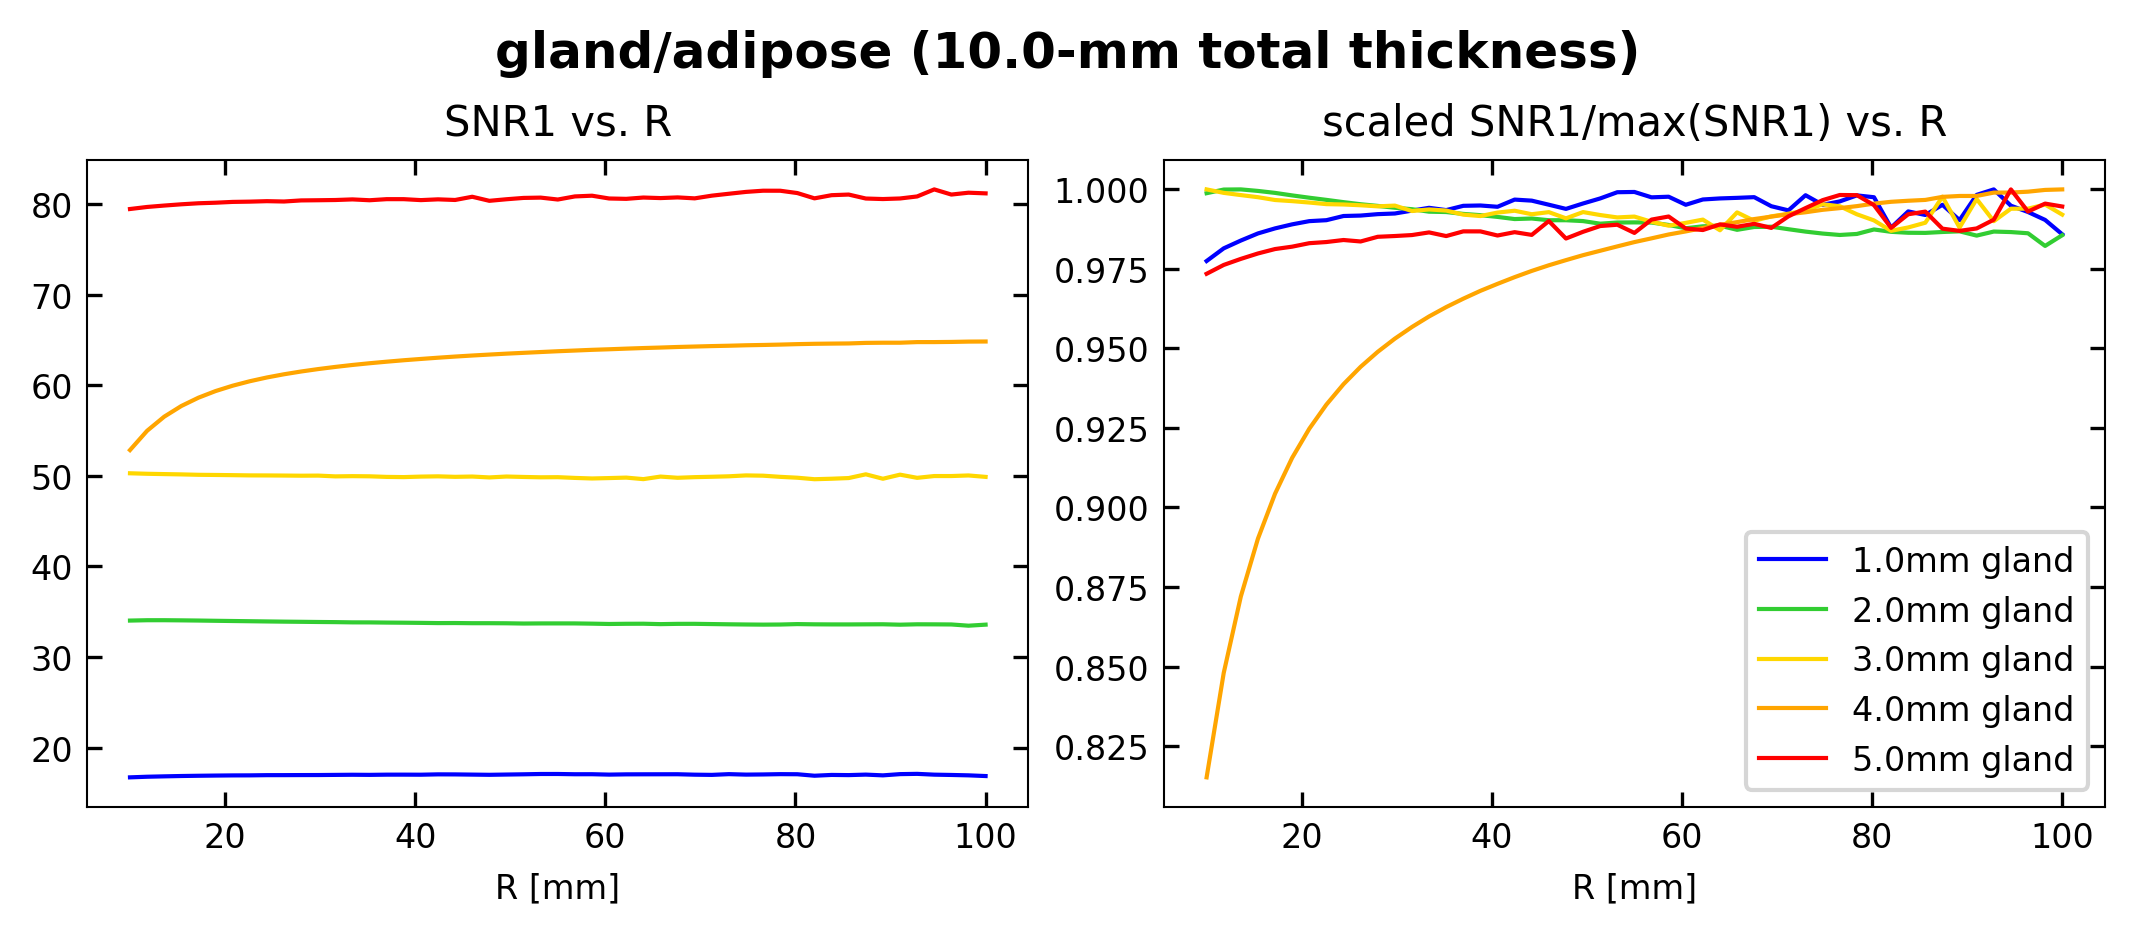

1.0


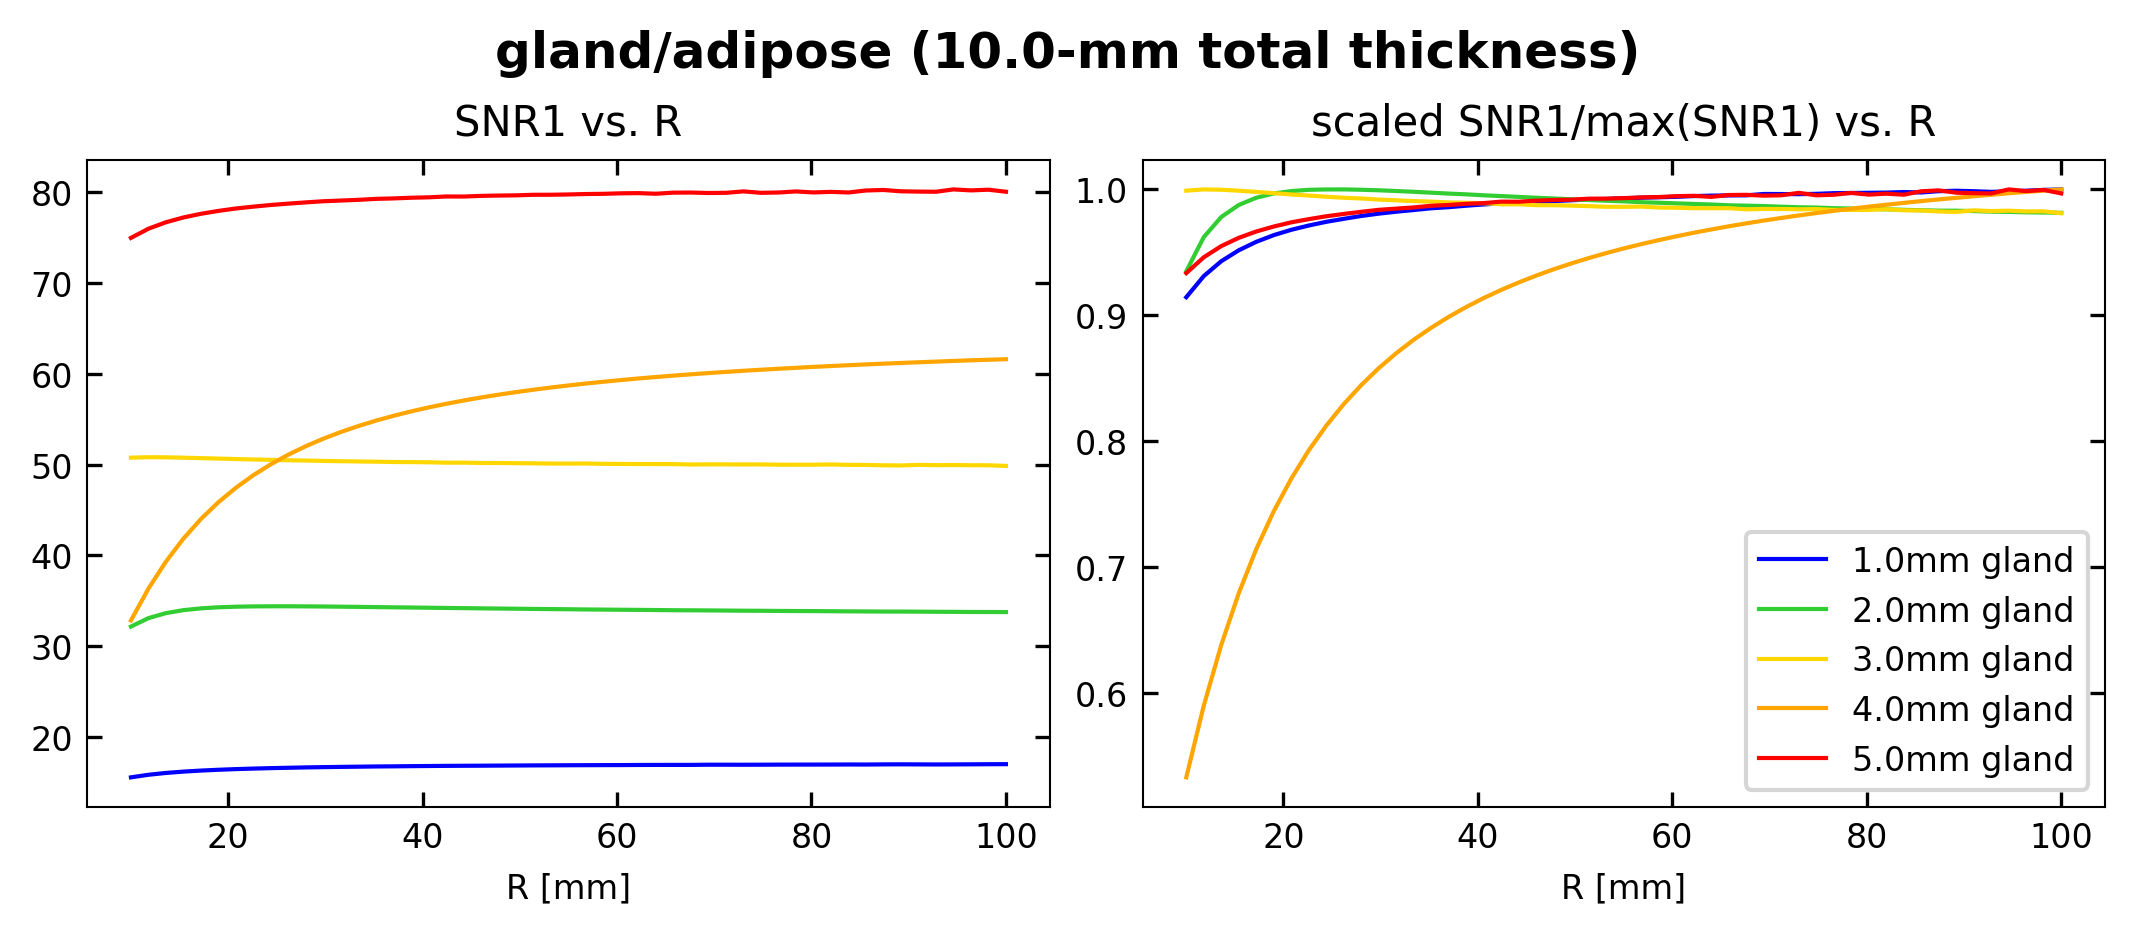

2.0


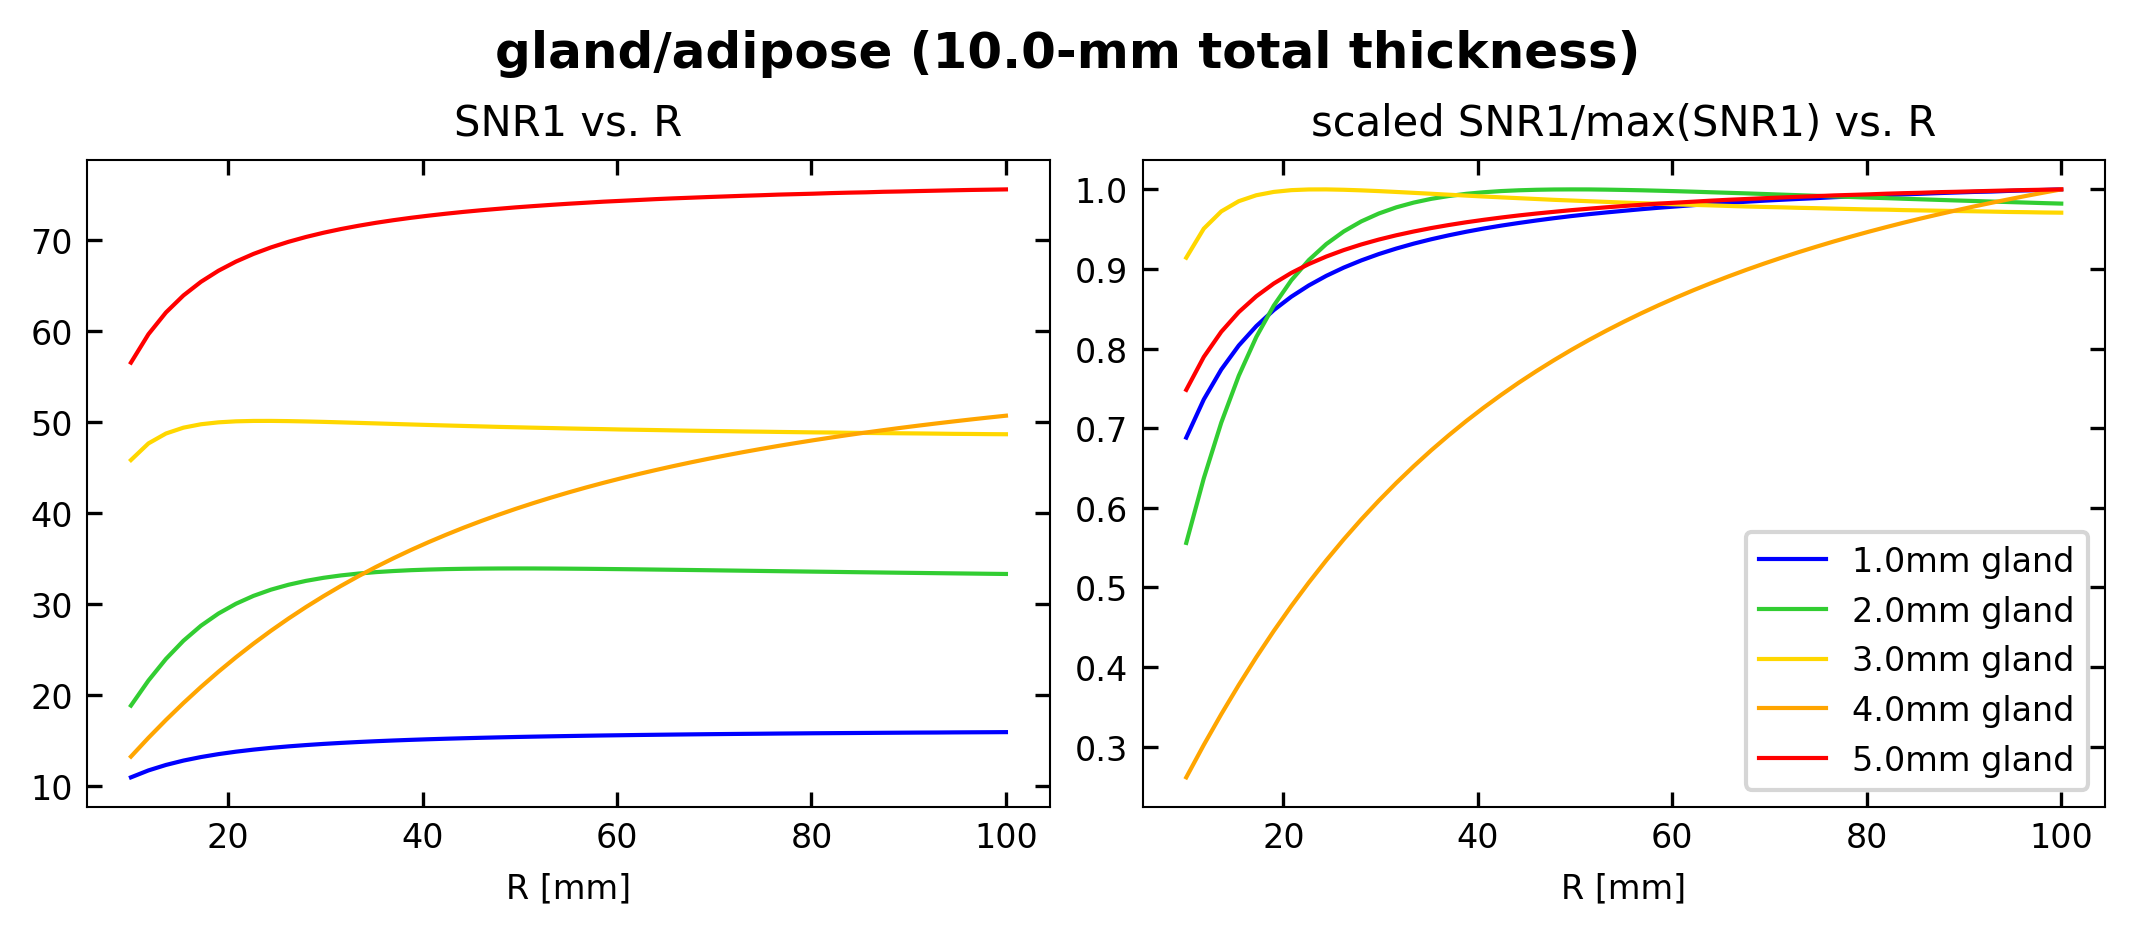

4.0


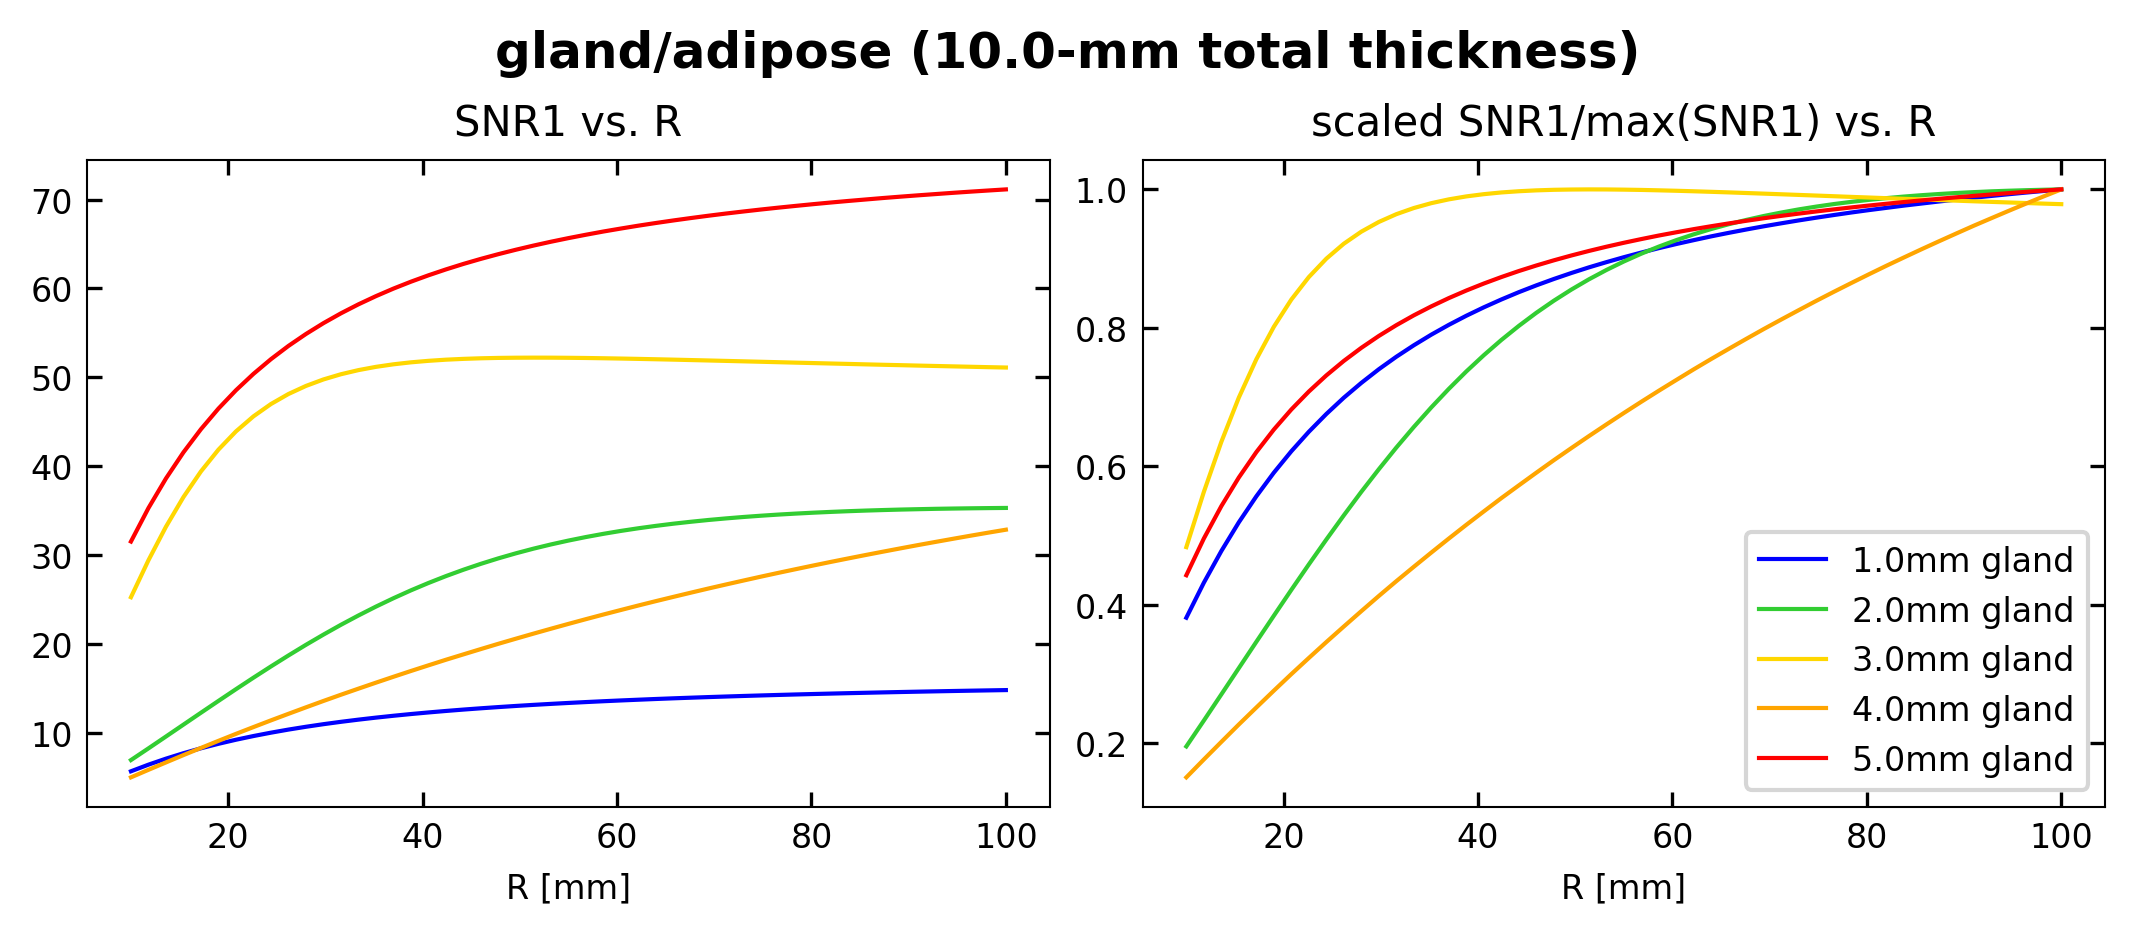

In [10]:
for dx in [0.5e-6, 1e-6, 2e-6, 4e-6]:
    print(dx*1e6)
    ## Recreating SNR1 vs. R for diff T1
    
    mat1 = gland
    mat2 = adip
    T_tot = 1e-2
    
    R_range = np.linspace(10e-3, 100e-3, 51)
    T1_range = 1e-3 * np.linspace(1, 5, 5)
    
    pars = jnp.array([(T1, R) for T1 in T1_range for R in R_range])
    
    partial_crlb_mono = partial(crlb.compute_crlb_mono, 
        E1 = 15,
        E2 = 25,
        dx = dx,
        T_tot = T_tot,
        Nx = 64, 
        obj_radius = 16e-6,
        I0_per_m2 = 1e15,
        mat1 = mat1, 
        mat2 = mat2
    )
    
    @jax.jit
    @jax.vmap
    def sweep_crlb_mono(pars):
        T1, R = pars
        return partial_crlb_mono(T1=T1, R=R)
    
    crlbs, snrs = sweep_crlb_mono(pars)
    
    snr_matrix = snrs[:,0].reshape([T1_range.size, R_range.size])
    
    
    fig, ax = plt.subplots(1, 2, figsize=[7,3], layout='constrained', dpi=300)
    
    for i, T1 in enumerate(T1_range):
        out = snr_matrix[i]
        T1_mm = T1*1e3
        ax[0].plot(R_range*1e3, out, label=f'{T1_mm:.1f}mm {mat1.name}')
        ax[1].plot(R_range*1e3, out/np.max(out), label=f'{T1_mm:.1f}mm {mat1.name}')
    
    fig.suptitle(f'{mat1.name}/{mat2.name} ({T_tot*1e3:.1f}-mm total thickness)', fontweight='bold')
    ax[0].set_title('SNR1 vs. R')
    ax[1].set_title('scaled SNR1/max(SNR1) vs. R')
    for axi in ax:
        axi.set_xlabel('R [mm]')
    plt.legend()
    plt.show()


# Polychromatic beam + spectral PCD

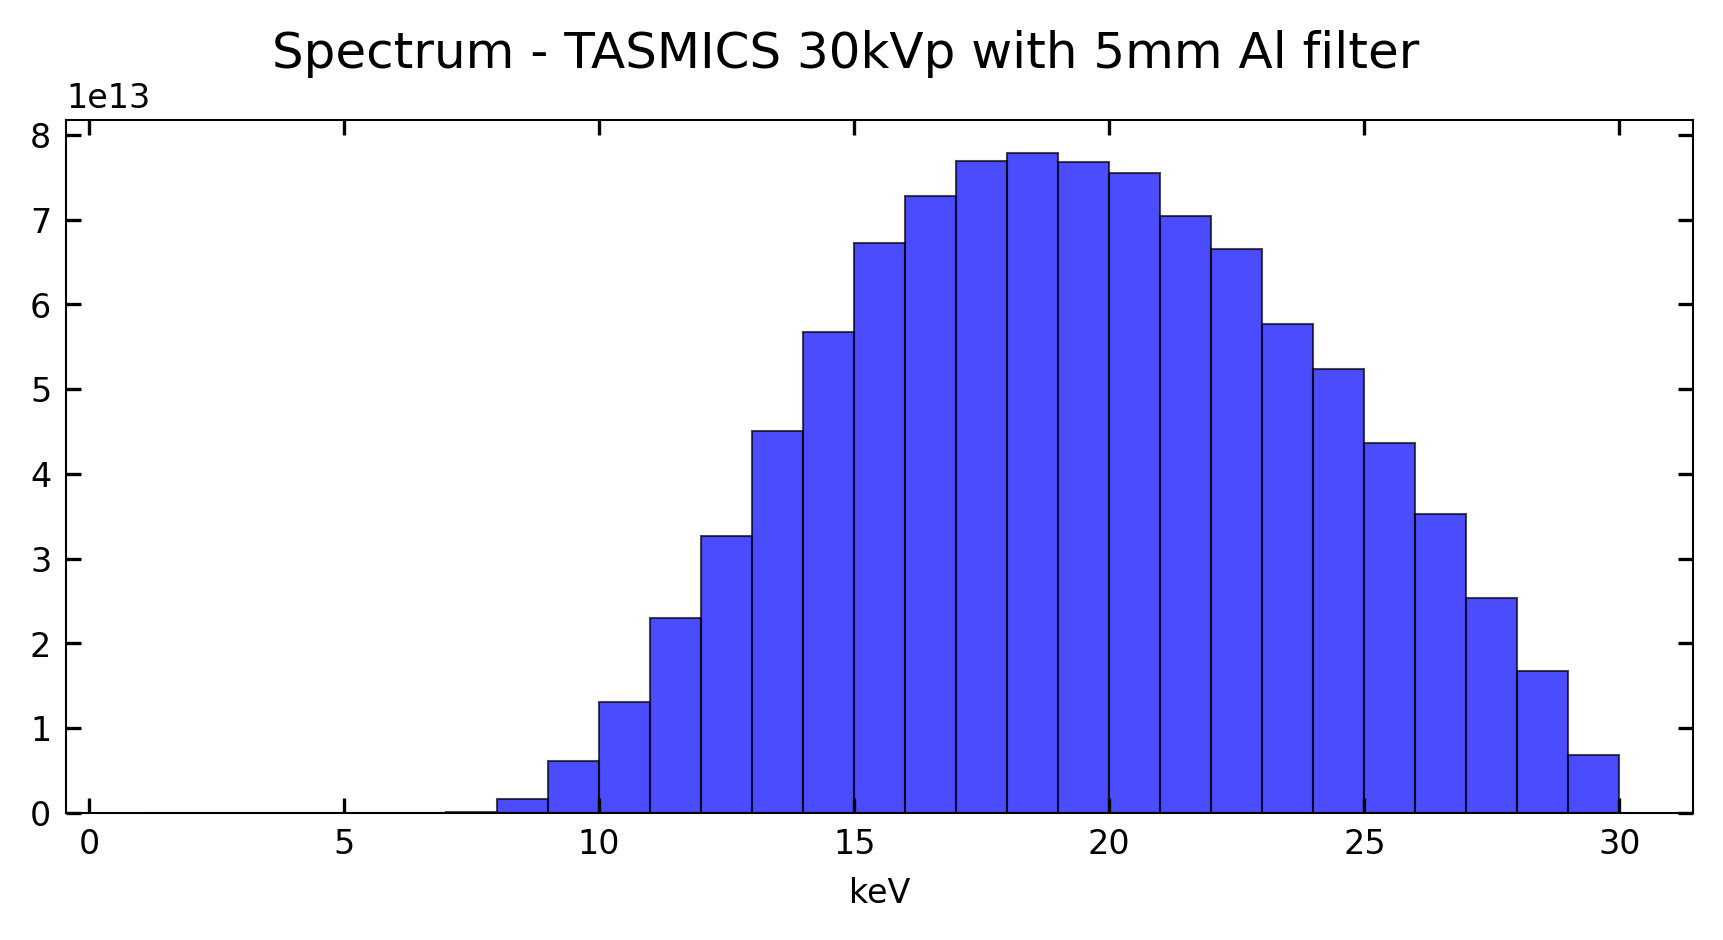

In [5]:
# Load polychromatic spectrum

I0 = 1e15
with open('inputs/tasmics_30kVp_5mmAl.csv', 'r') as f:
    spectrum = np.array([line.split(',') for line in f.readlines()[1:]], dtype=float).T
    spectrum[1] *= I0 / np.sum(spectrum[1])  # normalize total counts

# # upsample?
# evals = np.linspace(spectrum[0].min(), spectrum[0].max(), 100)
# specvals = np.interp(evals, spectrum[0], spectrum[1])
# spectrum = np.array([evals, specvals])

fig, ax = plt.subplots(figsize=[7,3])
fig.suptitle('Spectrum - TASMICS 30kVp with 5mm Al filter ')
ax.set_xlabel('keV')
ax.bar(spectrum[0], spectrum[1], width=1, align='center', edgecolor='k', linewidth=0.5, alpha=0.7)
plt.show()

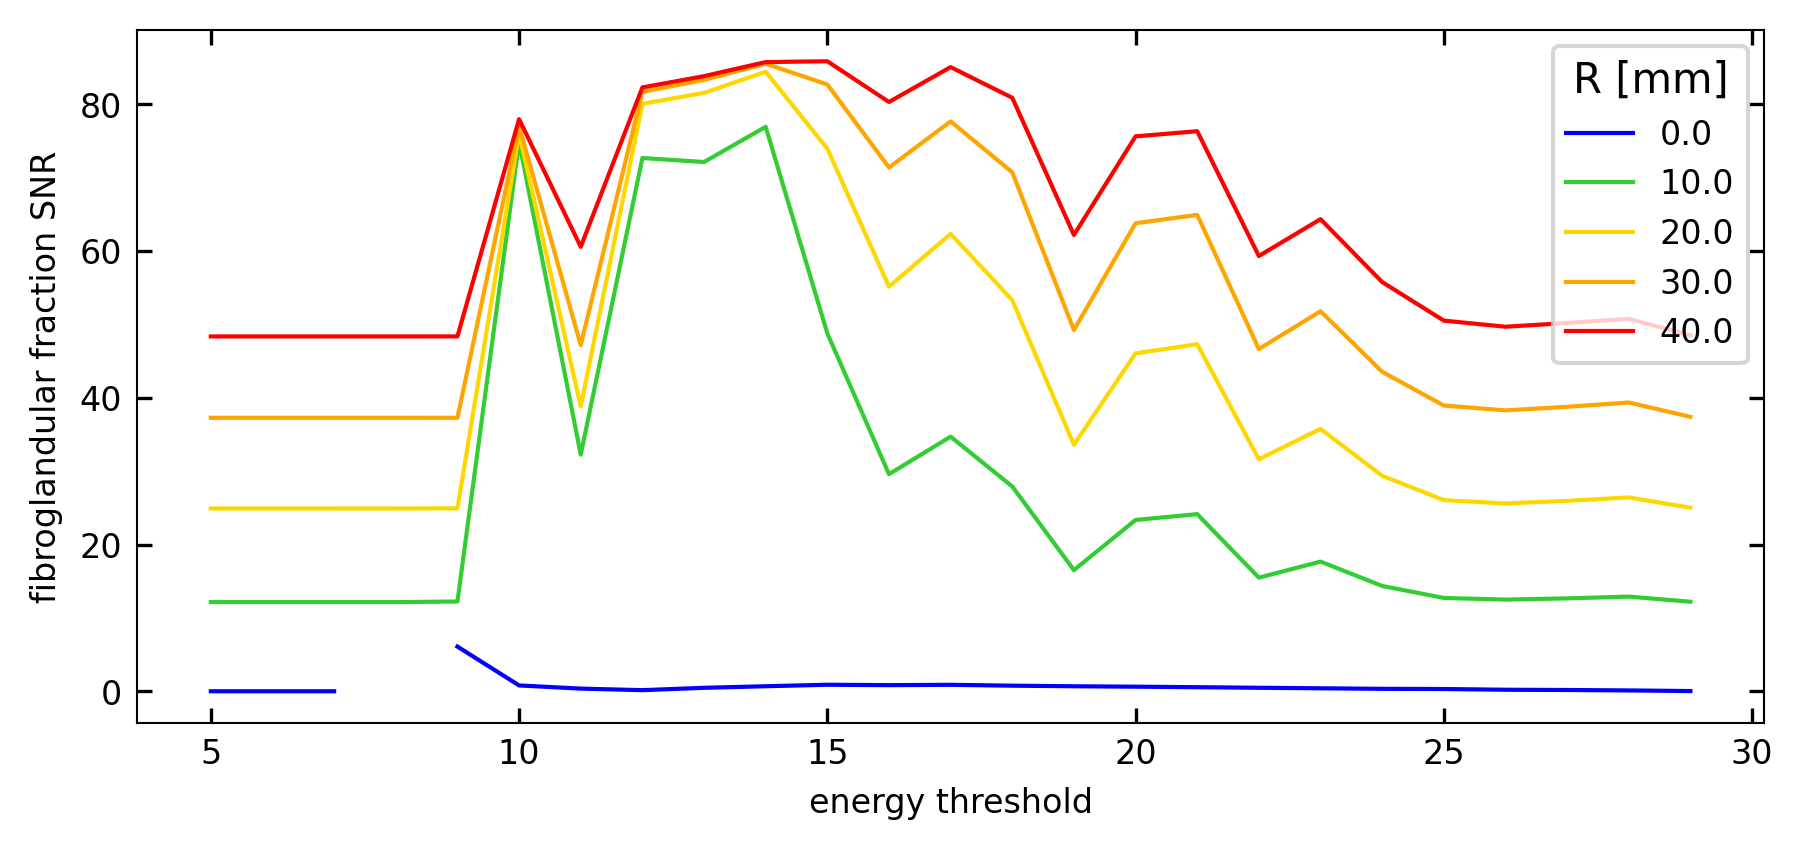

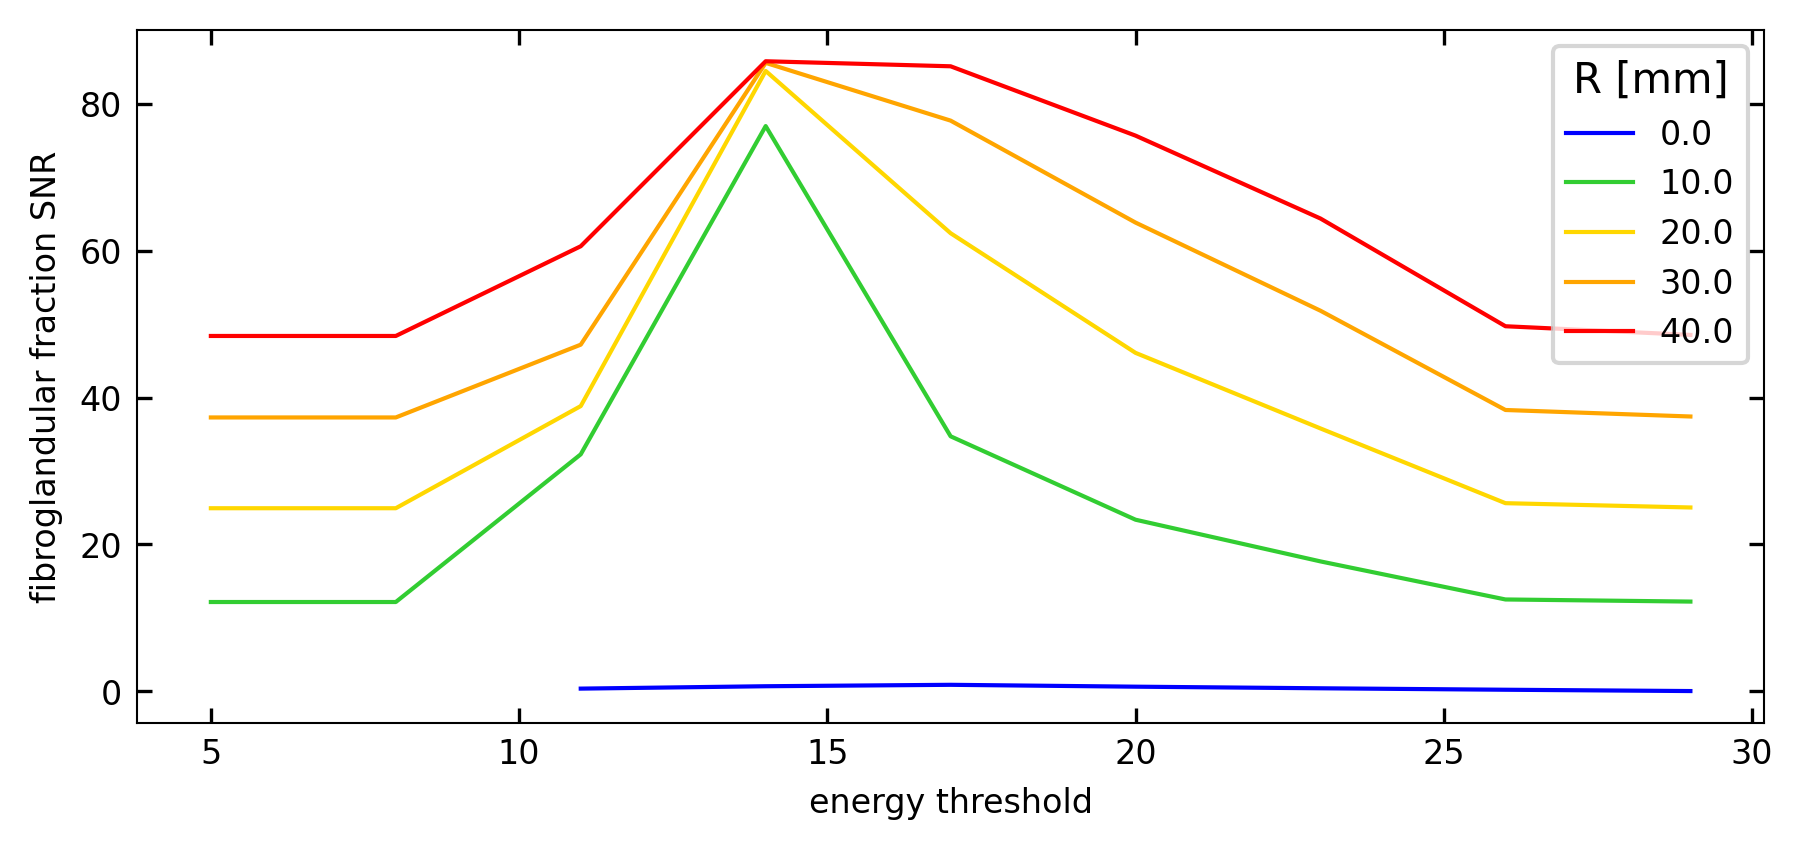

CPU times: user 3.4 s, sys: 172 ms, total: 3.57 s
Wall time: 2.07 s


In [7]:
%%time

E_threshs = np.arange(5, 31, 1)
Rs = np.linspace(0, 40, 5) * 1e-3

pars = jnp.array([(E, R) for E in E_threshs for R in Rs])

partial_frac_spectral = partial(crlb.compute_frac_spectral, 
    T1 = 1e-2,
    dx = 4e-6,
    spectrum = spectrum, 
    eta = np.ones(spectrum.shape[1]),
    T_tot = 5e-2,
    Nx = 64, 
    obj_radius = 32e-6,
    mat1 = gland,
    mat2 = adip       
)

@jax.jit
@jax.vmap
def sweep_frac_spectral(pars):
    E_thresh, R = pars
    return partial_frac_spectral(E_thresh, R)

var, snr = sweep_frac_spectral(pars)

snr_matrix = snr.reshape([E_threshs.size, Rs.size])

fig, ax = plt.subplots(1, 1, figsize=[7,3])
for i, R in enumerate(Rs):
    plt.plot(E_threshs, snr_matrix[:,i], label=R*1e3)
plt.legend(title='R [mm]')
plt.xlabel('energy threshold')
plt.ylabel('fibroglandular fraction SNR')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=[7,3])
for i, R in enumerate(Rs):
    plt.plot(E_threshs[::3], snr_matrix[::3,i], label=R*1e3)
plt.legend(title='R [mm]')
plt.xlabel('energy threshold')
plt.ylabel('fibroglandular fraction SNR')
plt.show()

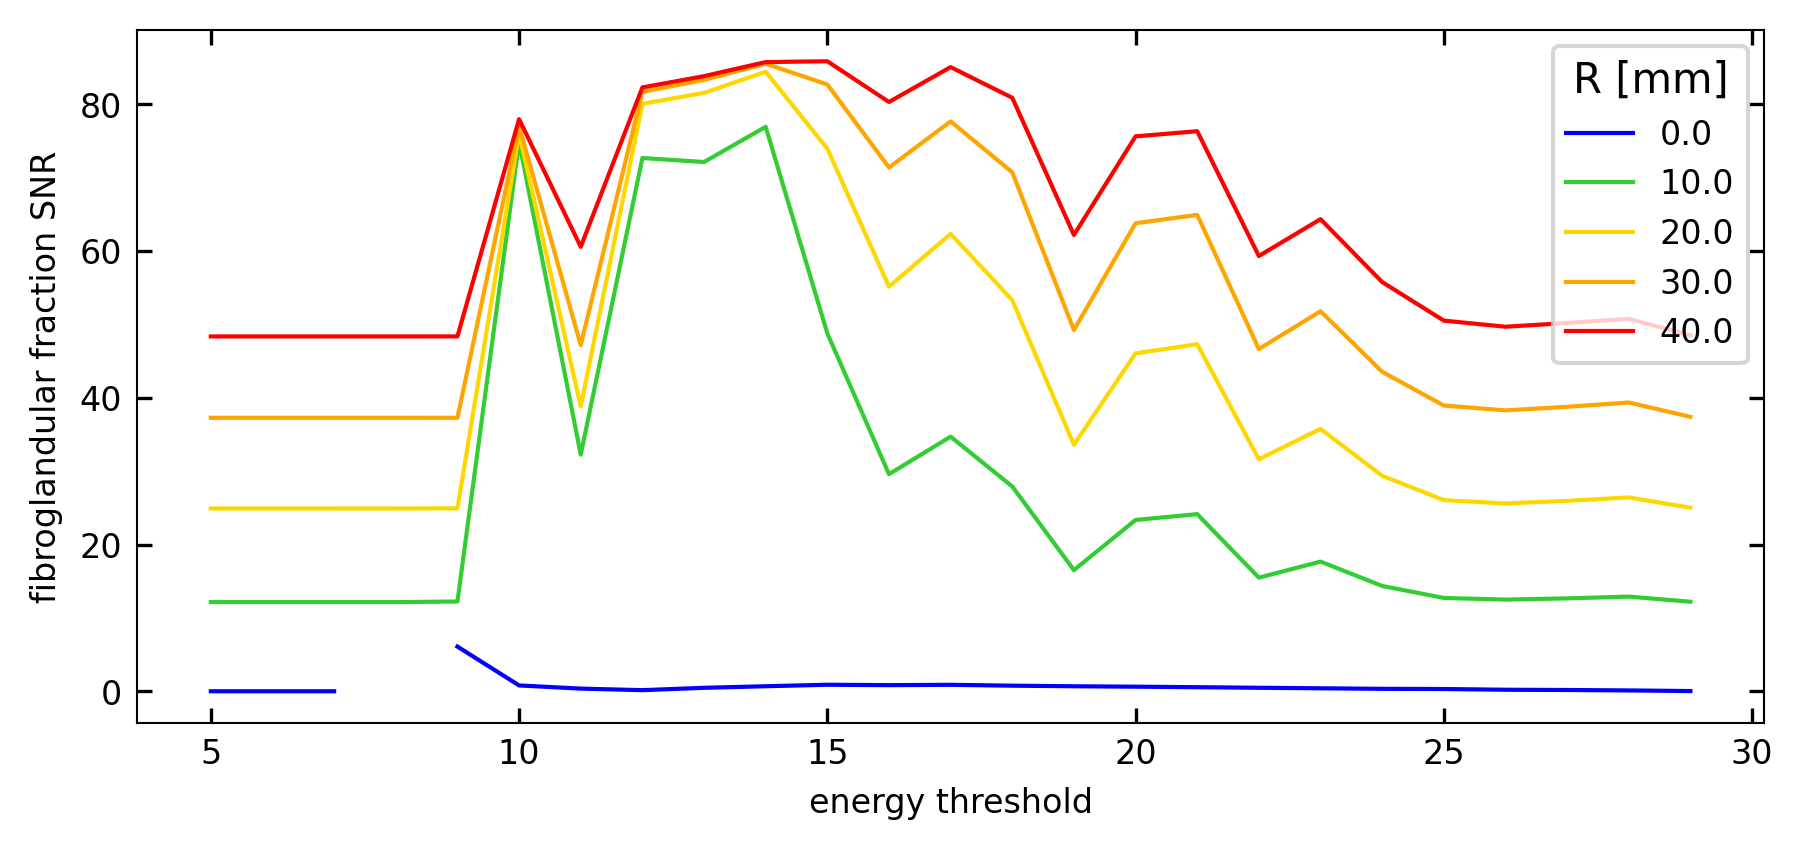

CPU times: user 3.16 s, sys: 174 ms, total: 3.34 s
Wall time: 1.86 s


In [6]:
%%time

E_threshs = np.arange(5, 31, 1)
Rs = np.linspace(0, 40, 5) * 1e-3

pars = jnp.array([(E, R) for E in E_threshs for R in Rs])

partial_frac_spectral = partial(crlb.compute_frac_spectral, 
    T1 = 1e-2,
    dx = 4e-6,
    spectrum = spectrum, 
    eta = np.ones(spectrum.shape[1]),
    T_tot = 5e-2,
    Nx = 64, 
    obj_radius = 32e-6,
    mat1 = gland,
    mat2 = adip,
    fwhm = 10e-6
)

@jax.jit
@jax.vmap
def sweep_frac_spectral(pars):
    E_thresh, R = pars
    return partial_frac_spectral(E_thresh, R)

var, snr = sweep_frac_spectral(pars)

snr_matrix = snr.reshape([E_threshs.size, Rs.size])

fig, ax = plt.subplots(1, 1, figsize=[7,3])
for i, R in enumerate(Rs):
    plt.plot(E_threshs, snr_matrix[:,i], label=R*1e3)
plt.legend(title='R [mm]')
plt.xlabel('energy threshold')
plt.ylabel('fibroglandular fraction SNR')
plt.show()


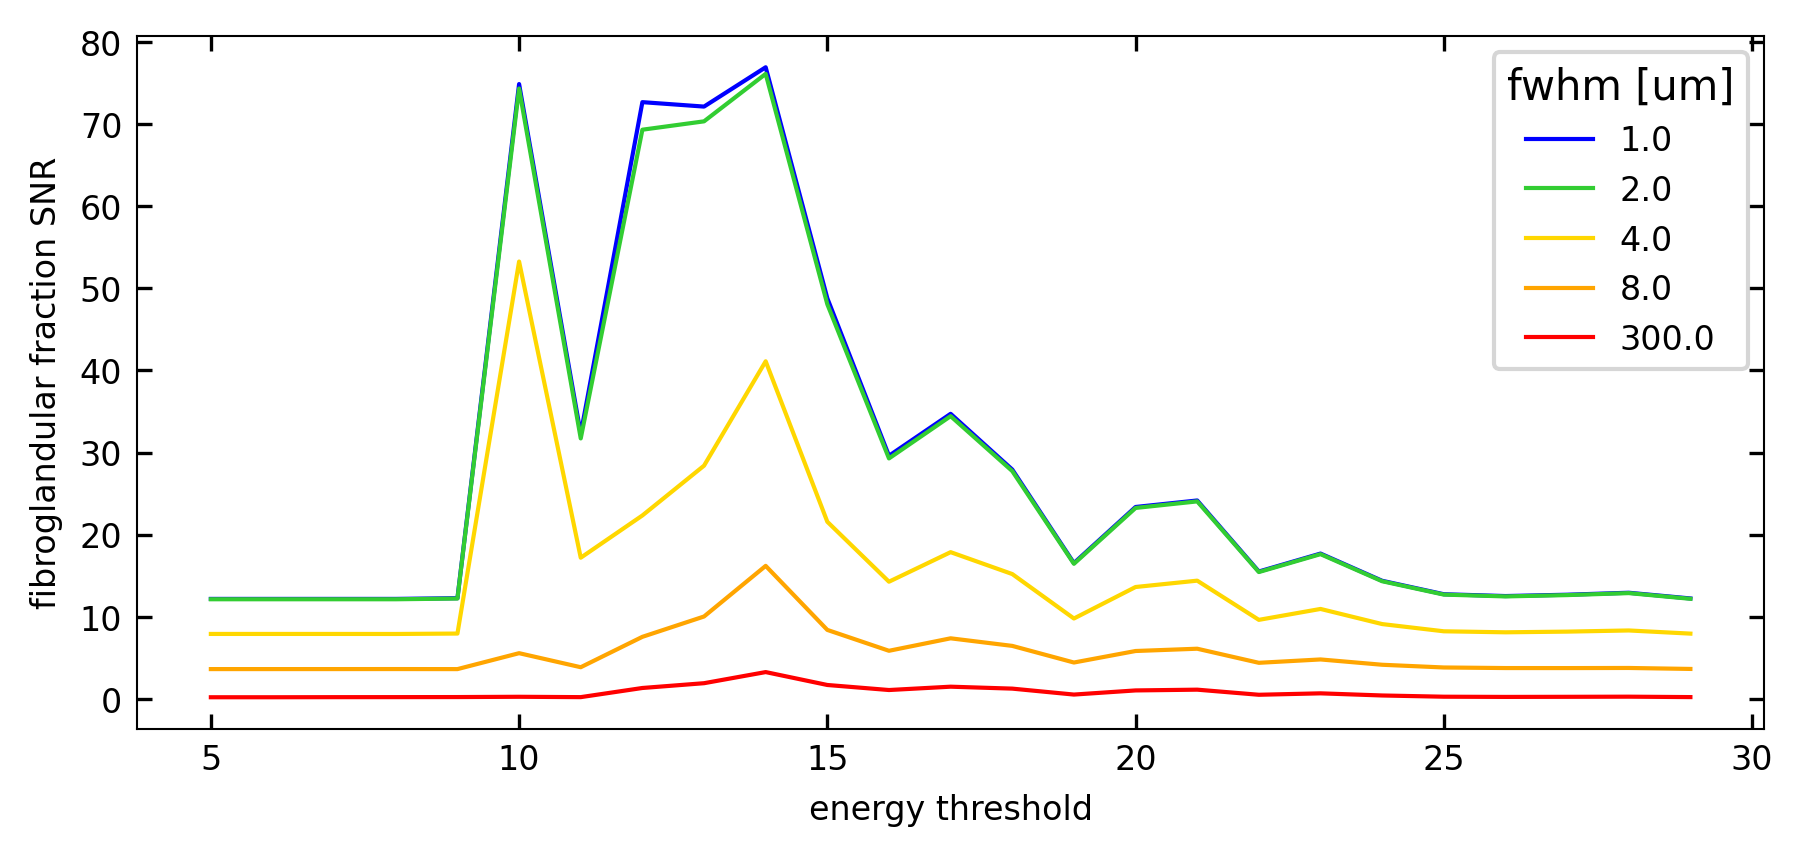

CPU times: user 8.95 s, sys: 148 ms, total: 9.1 s
Wall time: 2.24 s


In [7]:
%%time

E_threshs = np.arange(5, 31, 1)
fwhms = 1e-6 * np.array([1, 2, 4, 8, 300])

pars = jnp.array([(E, fwhm) for E in E_threshs for fwhm in fwhms])

partial_frac_spectral = partial(crlb.compute_frac_spectral, 
    R = 10e-3,
    T1 = 1e-2,
    dx = 4e-6,
    spectrum = spectrum, 
    eta = np.ones(spectrum.shape[1]),
    T_tot = 5e-2,
    Nx = 64, 
    obj_radius = 32e-6,
    mat1 = gland,
    mat2 = adip,
)

@jax.jit
@jax.vmap
def sweep_frac_spectral(pars):
    E_thresh, fwhm = pars
    return partial_frac_spectral(E_thresh, psf='gaussian', fwhm=fwhm)

var, snr = sweep_frac_spectral(pars)

# snr = jnp.nan_to_num(snr)

snr_matrix = snr.reshape([E_threshs.size, fwhms.size])

fig, ax = plt.subplots(1, 1, figsize=[7,3])
for i, fwhm in enumerate(fwhms):
    plt.plot(E_threshs, snr_matrix[:,i], label=fwhm*1e6, alpha=1)
plt.legend(title='fwhm [um]', loc='upper right')
plt.xlabel('energy threshold')
plt.ylabel('fibroglandular fraction SNR')
plt.show()


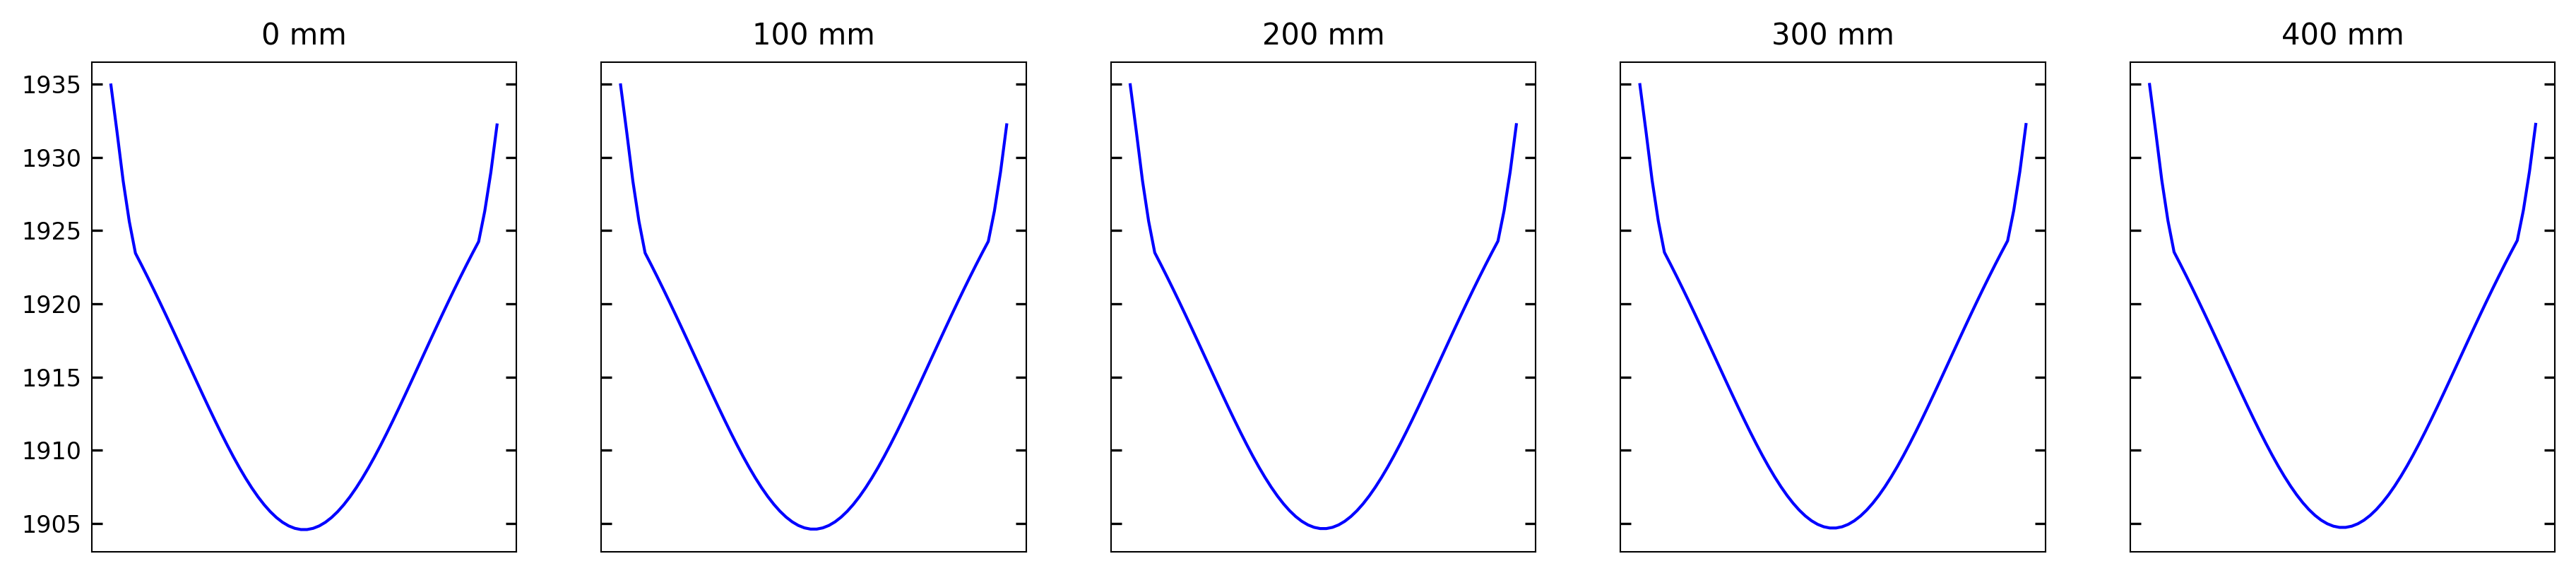

In [6]:
# test images

propdists = np.arange(0, 50, 10) * 1e-2
monospec = np.array([[10, 20], [1e12, 1e12]])
fig, ax = plt.subplots(1, len(propdists), figsize=[15,3], sharey=True)

for i, R in enumerate(propdists):
    test_img = crlb.compute_img_spectral(
        E_thresh = 14,
        R = R,
        T1 = 0.5e-2,
        dx = 4e-6,
        spectrum = spectrum, 
        eta = np.ones(spectrum.shape[1]),
        T_tot = 5e-2,
        Nx = 64, 
        obj_radius = 16e-6,
        mat1 = gland,
        mat2 = adip,
        fwhm = 300e-6)[0]
    # m = ax[i].imshow(test_img, vmax=1)
    ax[i].plot(test_img[test_img.shape[0]//2])
    # fig.colorbar(m, ax=ax[i])
    ax[i].set_title(f'{R*1e3:.0f} mm')
    ax[i].set_xticks([])
plt.show()

## Multi-parameter sweep

In [8]:
def plot_parallel_coordinates(snr_matrix, param_grids, param_names, top_n=1000, figsize=(10, 4), alpha=0.4, linewidth=3):
    """
    Create a parallel coordinates plot for a given SNR matrix and parameter sweep values.

    Parameters:
        snr_matrix : np.ndarray
            N-dimensional array of SNR values shaped to match the parameter sweep dimensions.
        param_grids : list of 1D np.ndarray
            List of arrays representing the sweep values for each parameter, in the same order as snr_matrix dimensions.
        param_names : list of str
            List of names for each parameter (for axis labeling).
        top_n : int, optional
            Number of top SNR combinations to plot (default: 1000).
        figsize : tuple, optional
            Size of the matplotlib figure (default: (10, 6)).
        alpha : float, optional
            Line transparency (default: 0.6).
    """
    assert len(param_grids) == snr_matrix.ndim, 'Number of parameter grids must match SNR matrix dimensions.'
    assert len(param_names) == snr_matrix.ndim, 'Number of parameter names must match SNR matrix dimensions.'

    # Create a meshgrid of all parameter combinations
    mesh = np.meshgrid(*param_grids, indexing='ij')
    param_stack = np.column_stack([m.ravel() for m in mesh])
    snr_flat = snr_matrix.ravel()

    # Remove NaNs
    valid_mask = ~np.isnan(snr_flat)
    param_stack = param_stack[valid_mask]
    snr_flat = snr_flat[valid_mask]

    # Normalize parameters to [0, 1] for plotting
    param_min = param_stack.min(axis=0)
    param_range = np.ptp(param_stack, axis=0) + 1e-12
    param_norm = (param_stack - param_min) / param_range

    # Select top-N SNR values
    top_n = min(top_n, len(snr_flat))
    top_indices = np.argsort(snr_flat)[-top_n:]
    snr_top = snr_flat[top_indices]

    # Normalize colormap to top-N range
    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=snr_top.min(), vmax=snr_top.max())

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    for i in top_indices:
        ax.plot(range(len(param_names)), param_norm[i], color=cmap(norm(snr_flat[i])), alpha=alpha, lw=linewidth)

    ax.set_xticks(range(len(param_names)))
    ax.set_xticklabels(param_names)
    ax.set_ylabel('Normalized Parameter Value')
    ax.set_title('SNR Parallel Coordinates')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, label='SNR')

    plt.tight_layout()
    plt.show()

    
    # Print true min and max for each parameter (non-normalized)
    print('Parameter value ranges (min to max):')
    for i, name in enumerate(param_names):
        print(f'  {name}: {param_stack[:, i].min():.6g} to {param_stack[:, i].max():.6g}')
    print()

    return None
    

In [9]:
%%time

F_fixed = 0.5
npts = 8
E_threshs = np.linspace(10, 31, npts)    # polychrom spectral threshold [keV]
Rs = 1e-3 * np.linspace(0, 40, npts)     # propagation distance [m]
T_tots = 1e-2 * np.linspace(1, 6, npts)  # total object thickness [m]
dxs = 1e-6 * np.linspace(1, 10, npts)    # pixel size [m]


pars = jnp.array([(E, R, T_tot, dx) 
                  for E in E_threshs 
                  for R in Rs
                  for T_tot in T_tots
                  for dx in dxs
                 ])

partial_frac_spectral = partial(crlb.compute_frac_spectral, 
    spectrum = spectrum, 
    eta = np.ones(spectrum.shape[1]),
    Nx = 64, 
    obj_radius = 100e-6,  #32e-6,
    mat1 = gland,
    mat2 = adip
)

@jax.jit
@jax.vmap
def sweep_frac_spectral(pars):
    E, R, T_tot, dx = pars
    return partial_frac_spectral(E_thresh=E, R=R, T1=F_fixed*T_tot, T_tot=T_tot, dx=dx)

var, snr = sweep_frac_spectral(pars)


## show
snr_matrix = snr.reshape([E_threshs.size, Rs.size, T_tots.size, dxs.size])

param_grids = [E_threshs, Rs, T_tots, dxs]
param_names = ['E_thresh', 'R', 'T_tot', 'dx']

plot_parallel_coordinates(snr_matrix, param_grids, param_names, top_n=500)


CPU times: user 3 s, sys: 117 ms, total: 3.12 s
Wall time: 1.79 s


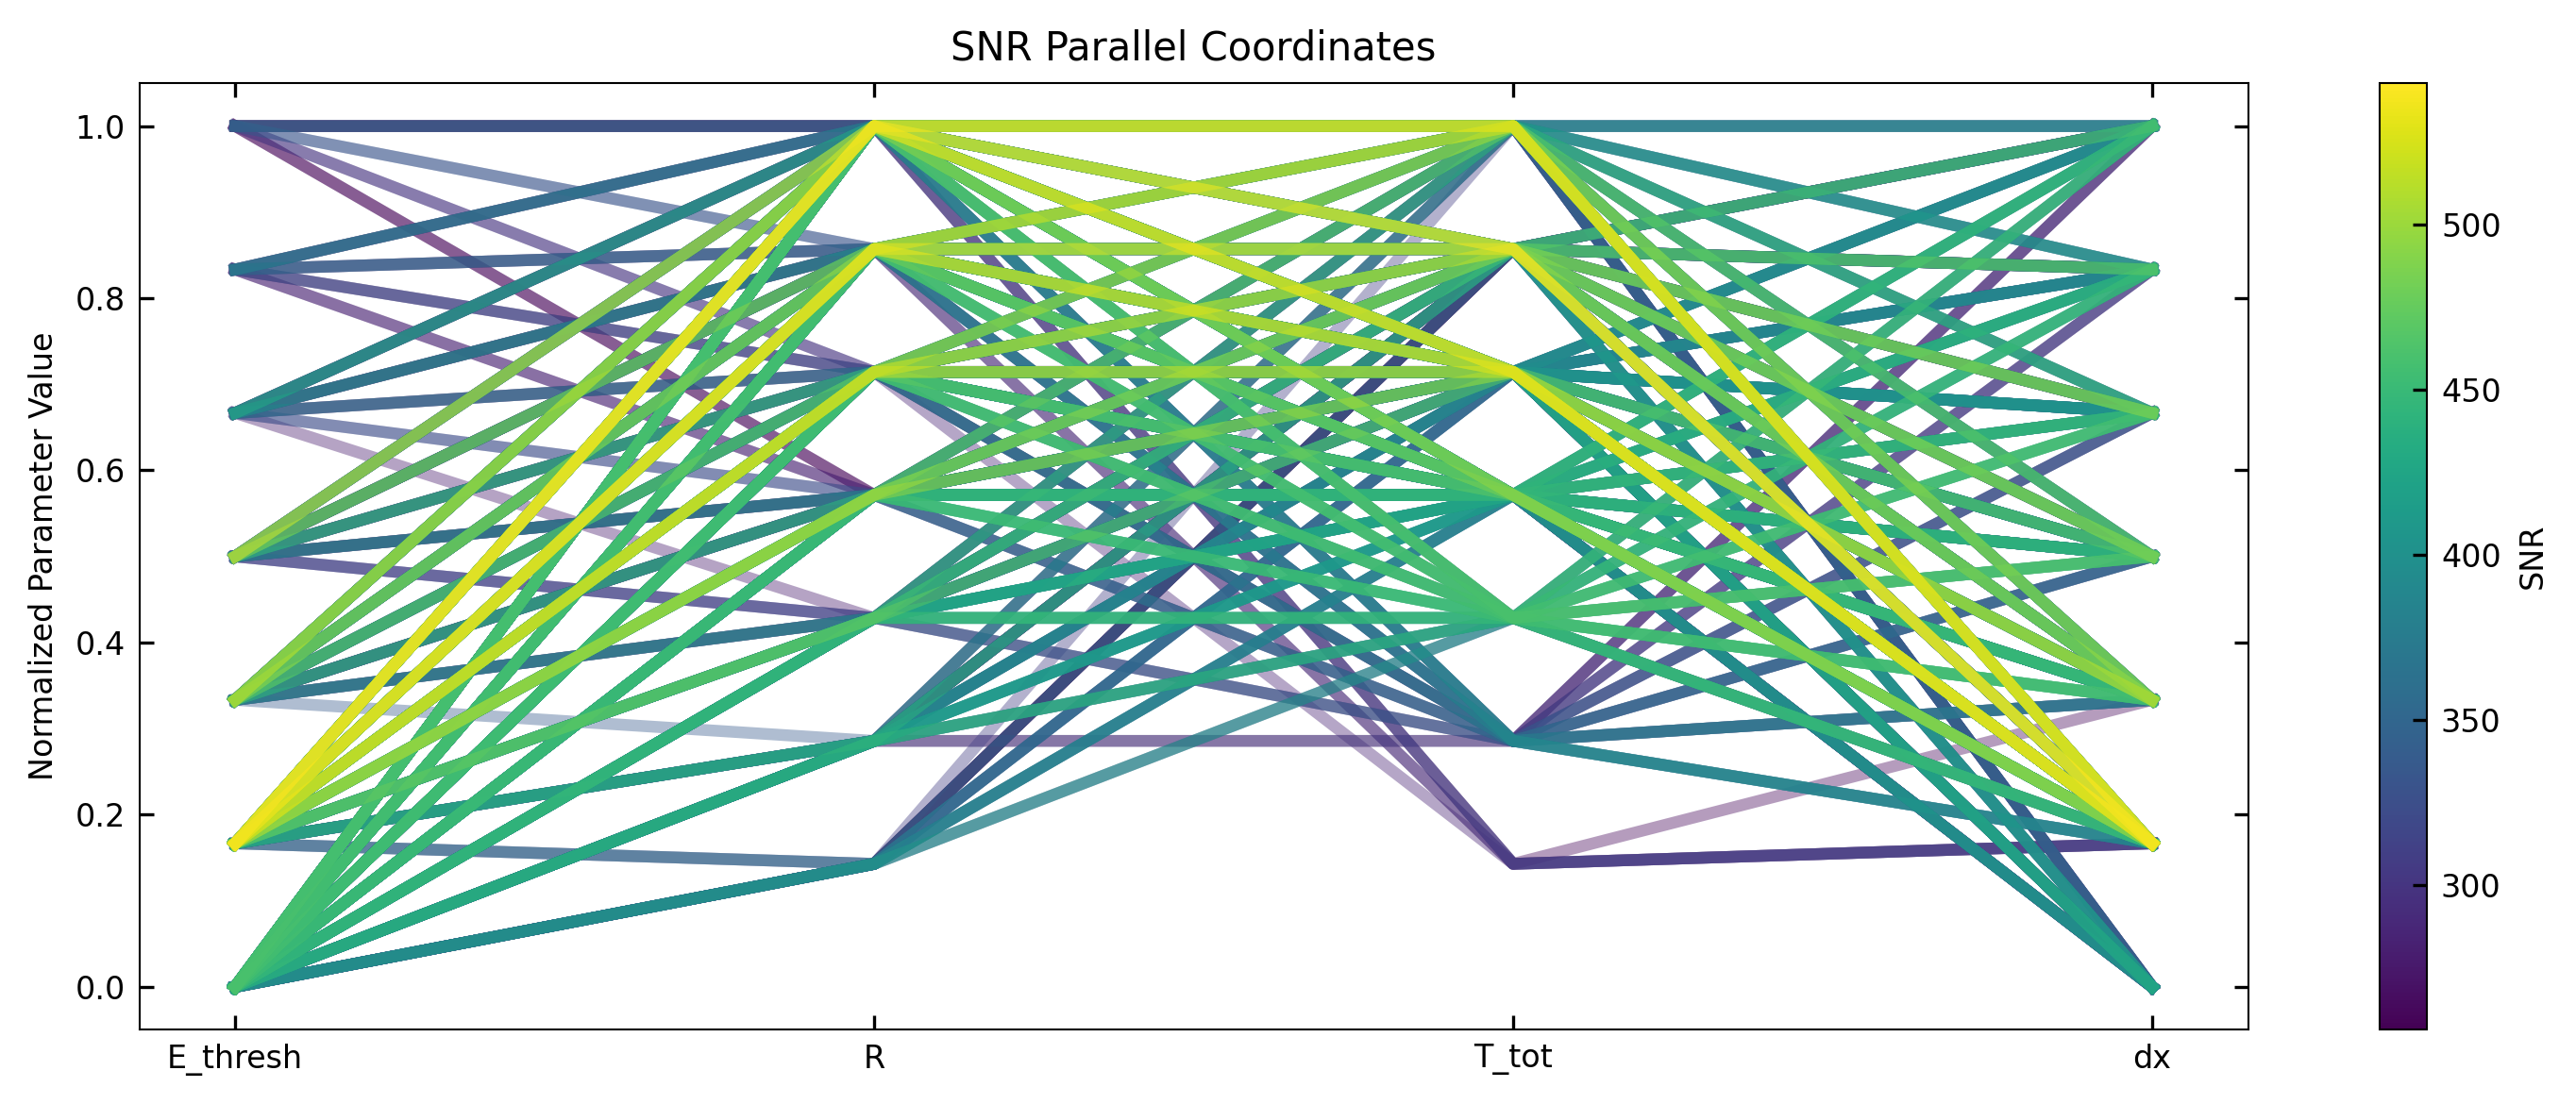

Parameter value ranges (min to max):
  E_thresh: 10 to 28
  R: 0 to 0.04
  T_tot: 0.01 to 0.06
  dx: 2.28571e-06 to 1e-05

CPU times: user 14.9 s, sys: 3.65 s, total: 18.5 s
Wall time: 9.95 s


In [10]:
%%time

## show
snr_matrix = snr.reshape([E_threshs.size, Rs.size, T_tots.size, dxs.size])

param_grids = [E_threshs, Rs, T_tots, dxs]
param_names = ['E_thresh', 'R', 'T_tot', 'dx']

plot_parallel_coordinates(snr_matrix, param_grids, param_names, top_n=500)


In [12]:
# Flatten snr_matrix and parameter grids
mesh = np.meshgrid(*param_grids, indexing='ij')
param_stack = np.column_stack([m.ravel() for m in mesh])
snr_flat = snr_matrix.ravel()

# Remove NaNs
valid_mask = ~np.isnan(snr_flat)
param_stack = param_stack[valid_mask]
snr_flat = snr_flat[valid_mask]


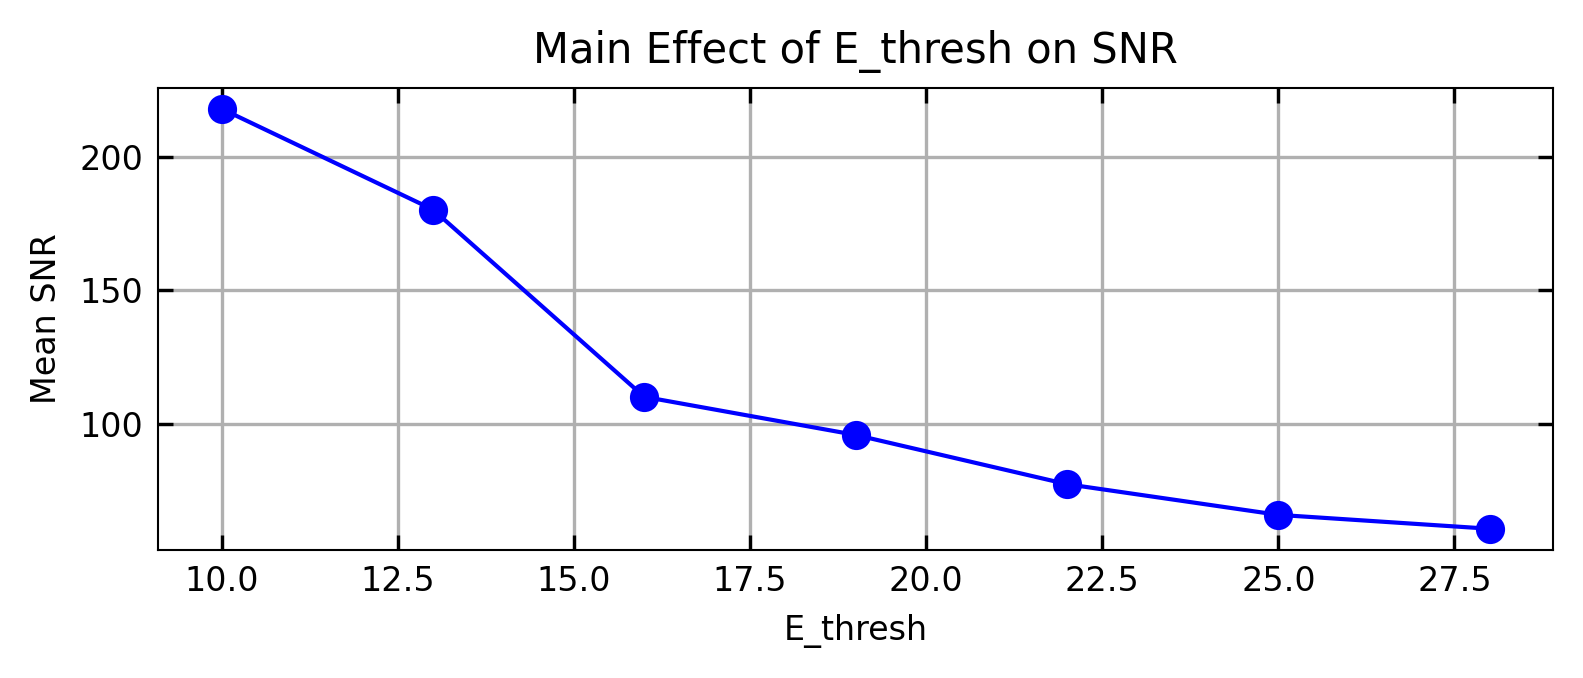

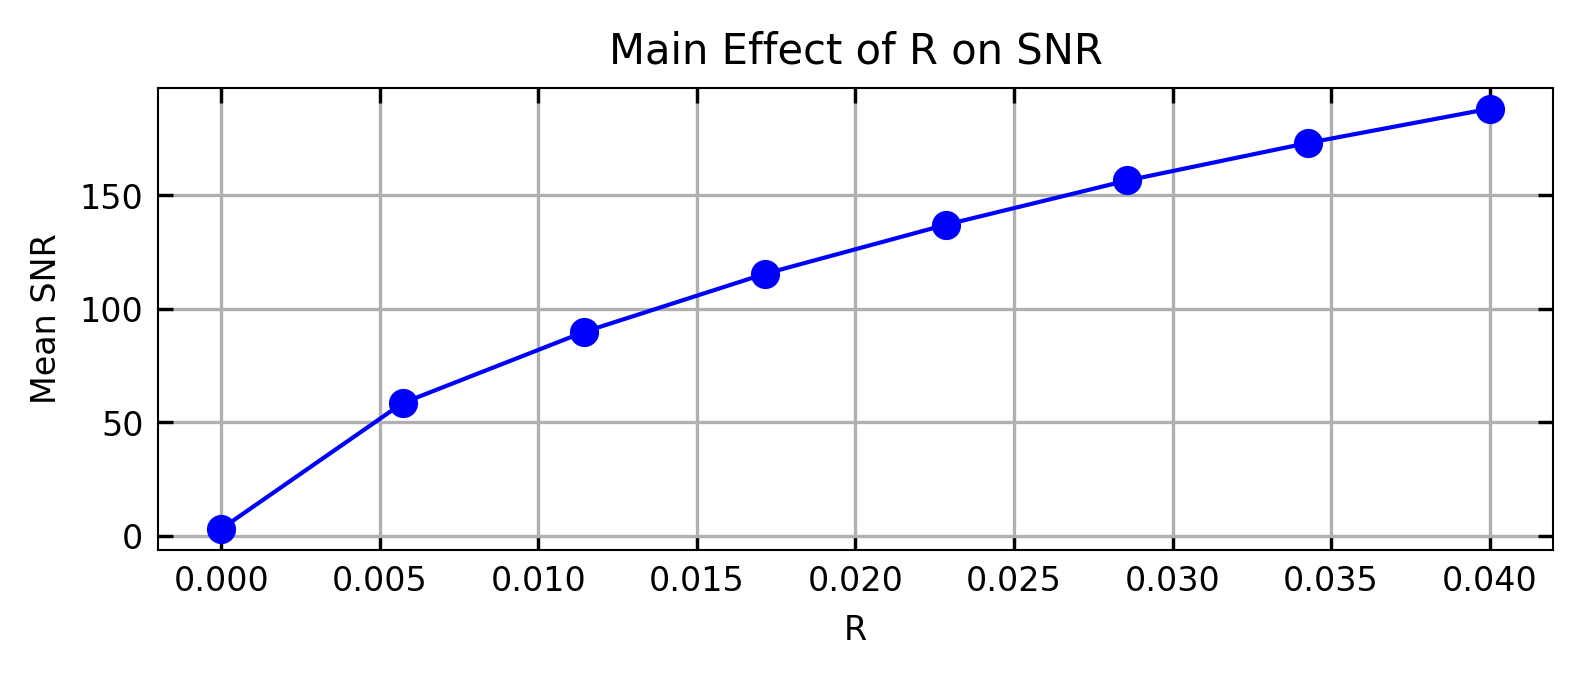

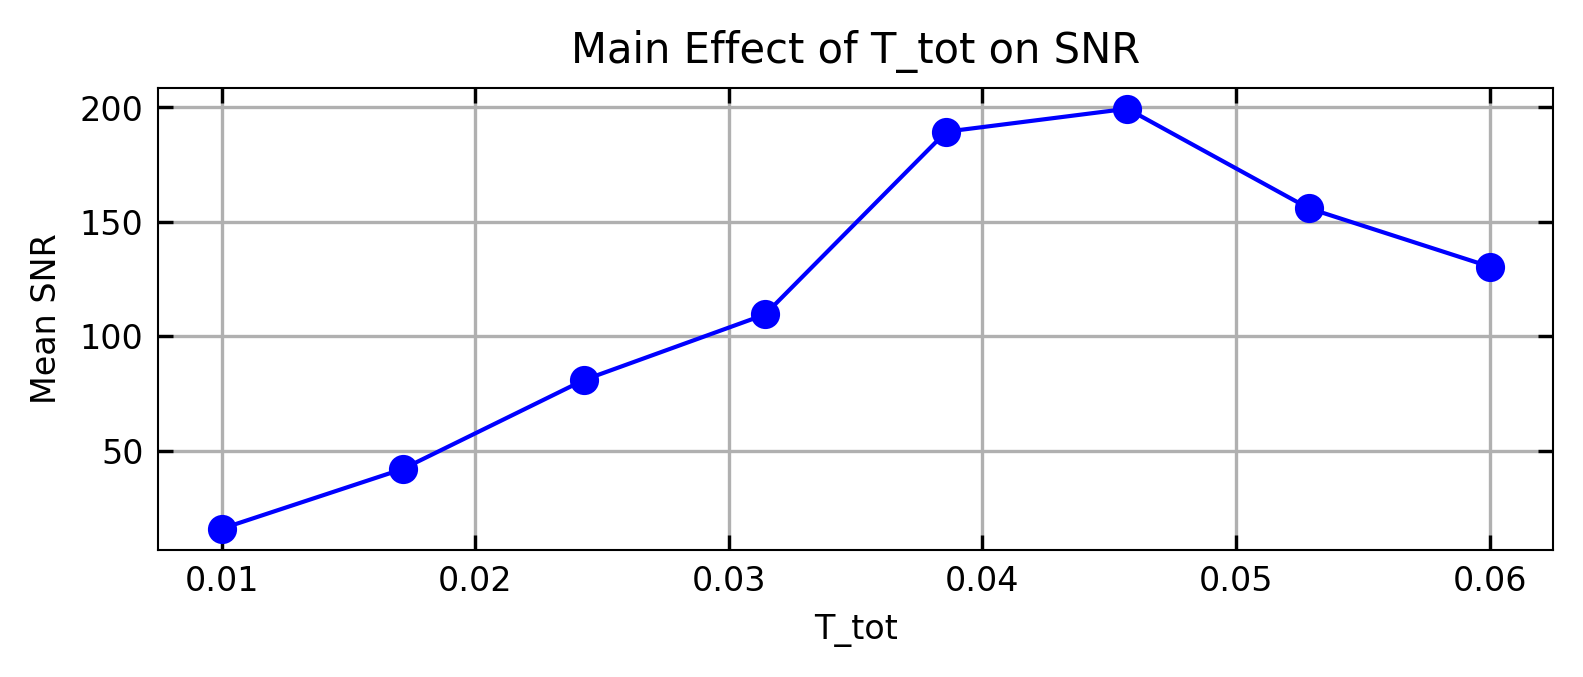

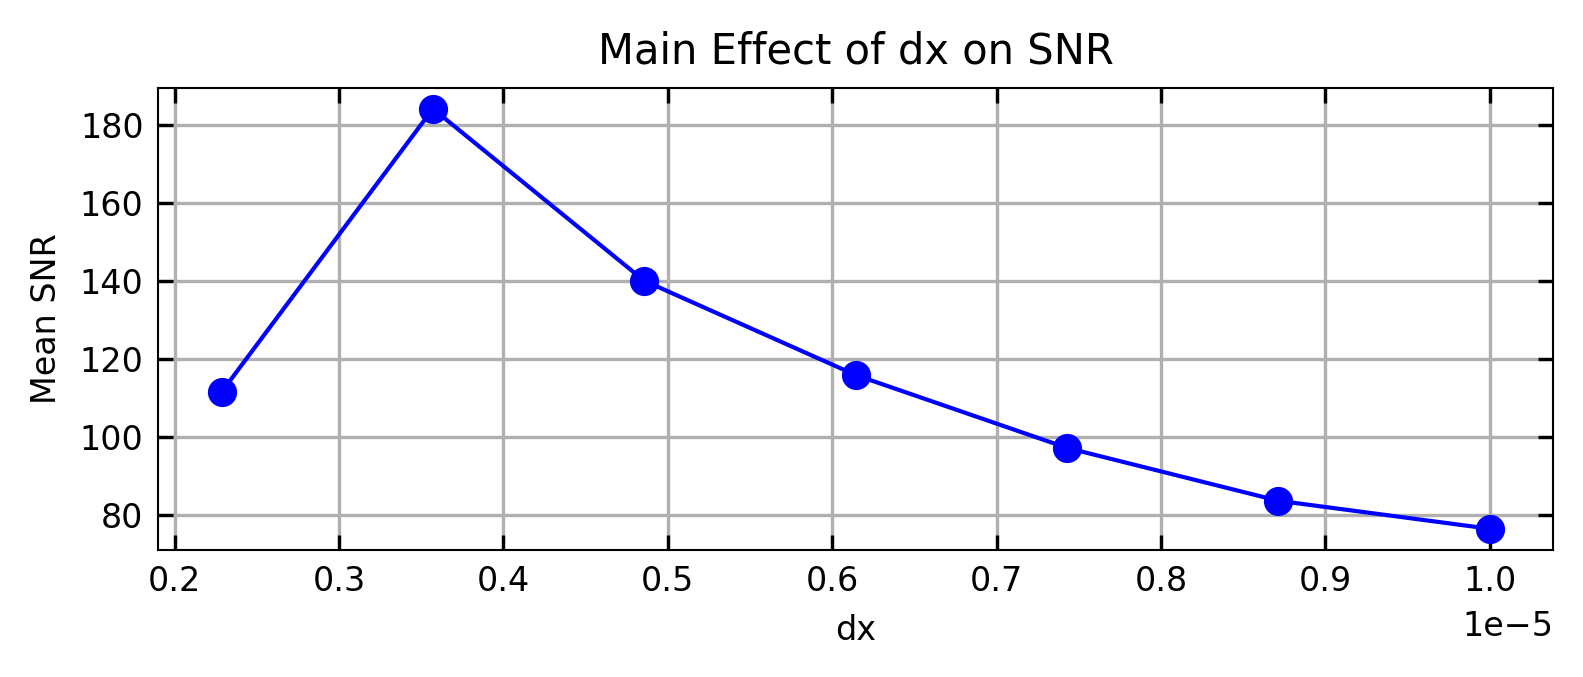

In [14]:
# Mean SNR vs parameter

for i, name in enumerate(param_names):
    unique_vals = np.unique(param_stack[:, i])
    mean_snr = [snr_flat[param_stack[:, i] == v].mean() for v in unique_vals]

    fig, ax = plt.subplots(1, 1, figsize=[6,2])
    plt.plot(unique_vals, mean_snr, marker='o')
    plt.xlabel(name)
    plt.ylabel('Mean SNR')
    plt.title(f'Main Effect of {name} on SNR')
    plt.grid(True)


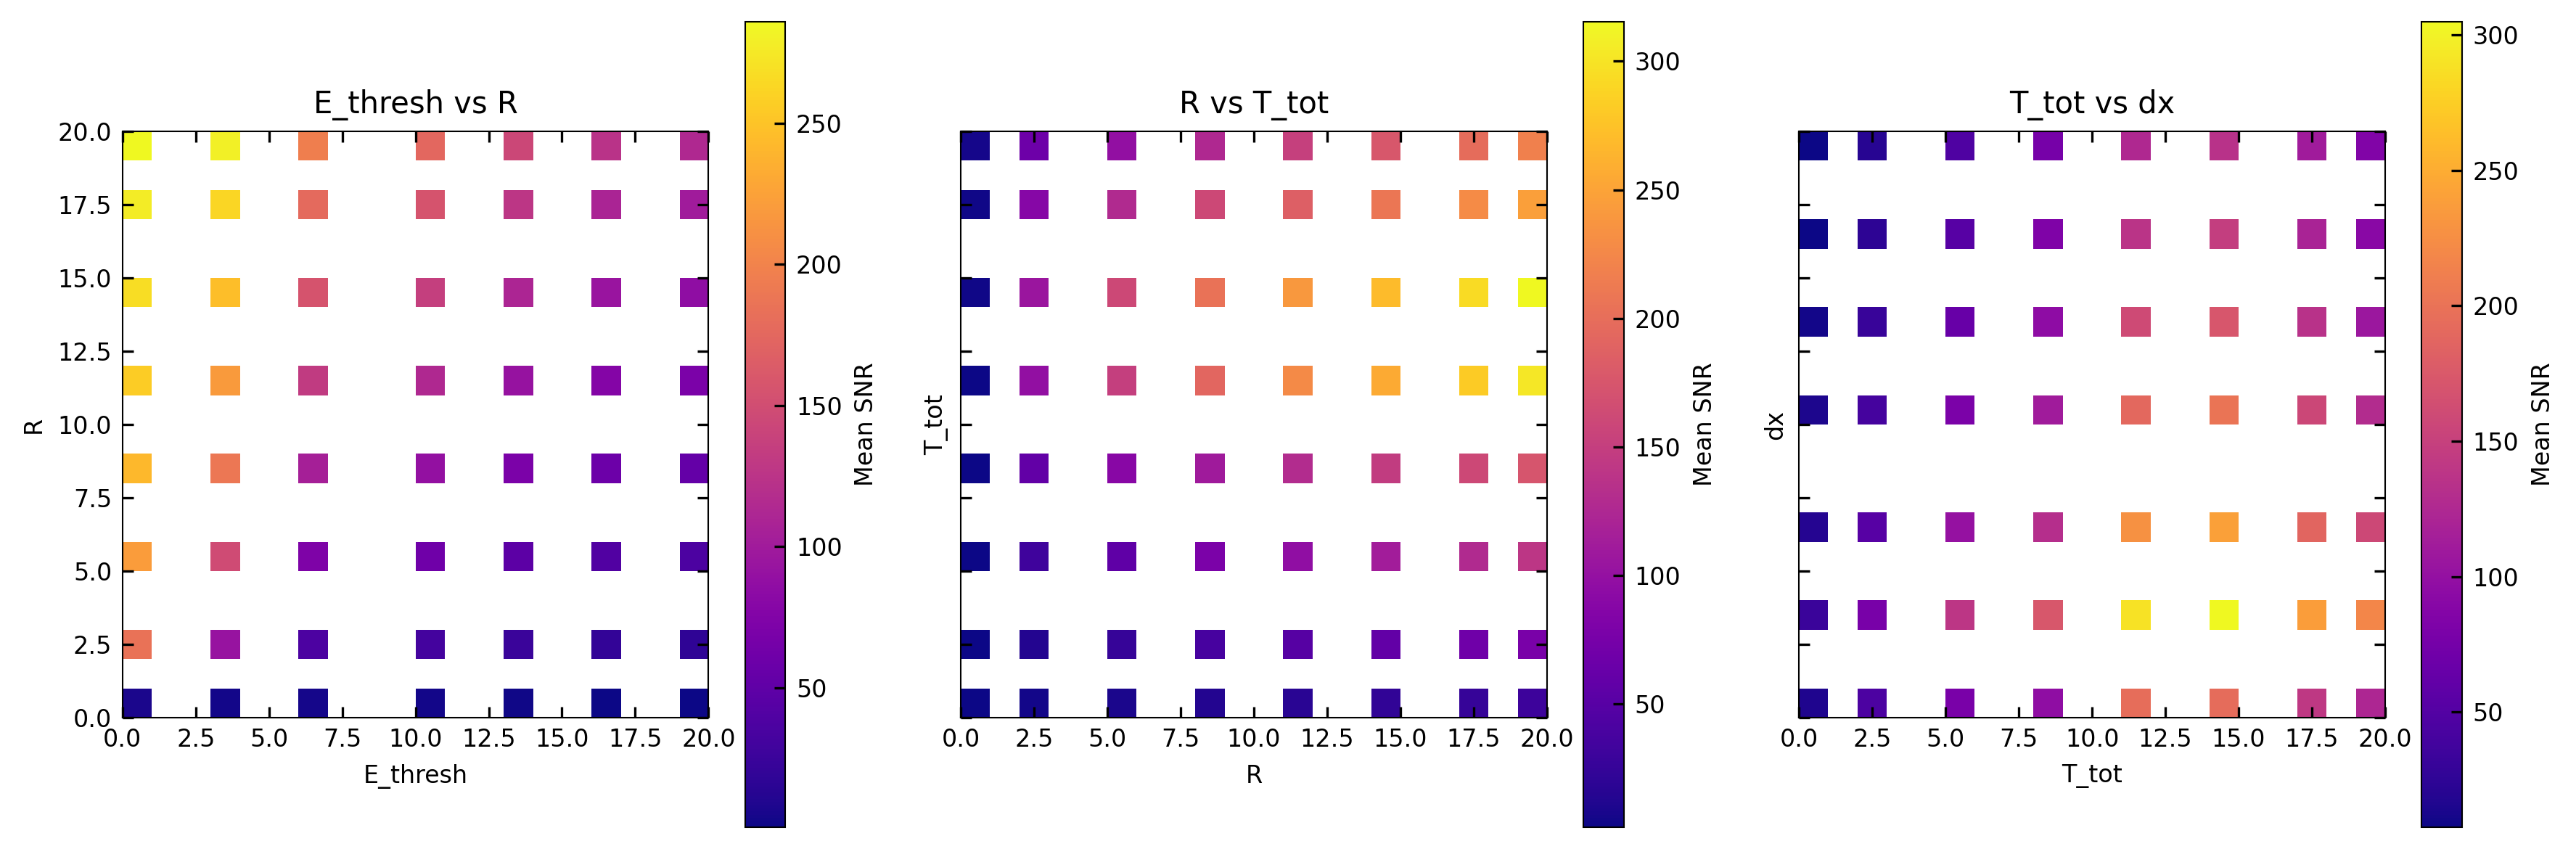

In [25]:
def parallel_coords_heatmap(param_stack, snr_values, param_names, bins=10, agg_fn=np.nanmean):
    """
    Create a heatmap version of a parallel coordinates plot, showing mean SNR between adjacent parameter bins.

    Parameters
    ----------
    param_stack : ndarray, shape (N, D)
        Flattened array of parameter combinations (N = number of combos, D = number of parameters).
    snr_values : ndarray, shape (N,)
        Corresponding SNR values for each parameter combo (can contain NaNs).
    param_names : list of str, length D
        Names of each parameter (for labels).
    bins : int
        Number of bins to use per parameter.
    agg_fn : callable
        Aggregation function (e.g., np.nanmean, np.nanmax).
    """
    D = param_stack.shape[1]

    # Normalize each parameter to 0–1 range for binning
    param_norm = (param_stack - np.min(param_stack, axis=0)) / np.ptp(param_stack, axis=0)

    fig, axes = plt.subplots(1, D - 1, figsize=(4 * (D - 1), 4), sharey=True)
    if D == 2:
        axes = [axes]

    for i in range(D - 1):
        x_bins = np.linspace(0, 1, bins + 1)
        y_bins = np.linspace(0, 1, bins + 1)
        heatmap = np.full((bins, bins), np.nan)

        # Digitize parameters i and i+1
        x_idx = np.digitize(param_norm[:, i], x_bins) - 1
        y_idx = np.digitize(param_norm[:, i + 1], y_bins) - 1

        # Clip to bin range
        x_idx = np.clip(x_idx, 0, bins - 1)
        y_idx = np.clip(y_idx, 0, bins - 1)

        # Aggregate SNR in each bin pair
        for xi in range(bins):
            for yi in range(bins):
                mask = (x_idx == xi) & (y_idx == yi)
                if np.any(mask):
                    heatmap[yi, xi] = agg_fn(snr_values[mask])

        im = axes[i].imshow(
            heatmap,
            origin='lower',
            cmap='plasma',
            extent=[0, bins, 0, bins],
            interpolation='nearest'
        )
        axes[i].set_xlabel(f'{param_names[i]}')
        axes[i].set_ylabel(f'{param_names[i + 1]}')
        axes[i].set_title(f'{param_names[i]} vs {param_names[i + 1]}')

        cbar = plt.colorbar(im, ax=axes[i])
        cbar.set_label('Mean SNR')

    plt.tight_layout()
    plt.show()


# Usage
snr_flat = snr_matrix.flatten()
valid = ~np.isnan(snr_flat)
param_stack_valid = param_stack[valid]
snr_valid = snr_flat[valid]

parallel_coords_heatmap(param_stack_valid, snr_valid, param_names, bins=20, agg_fn=np.nanmean)


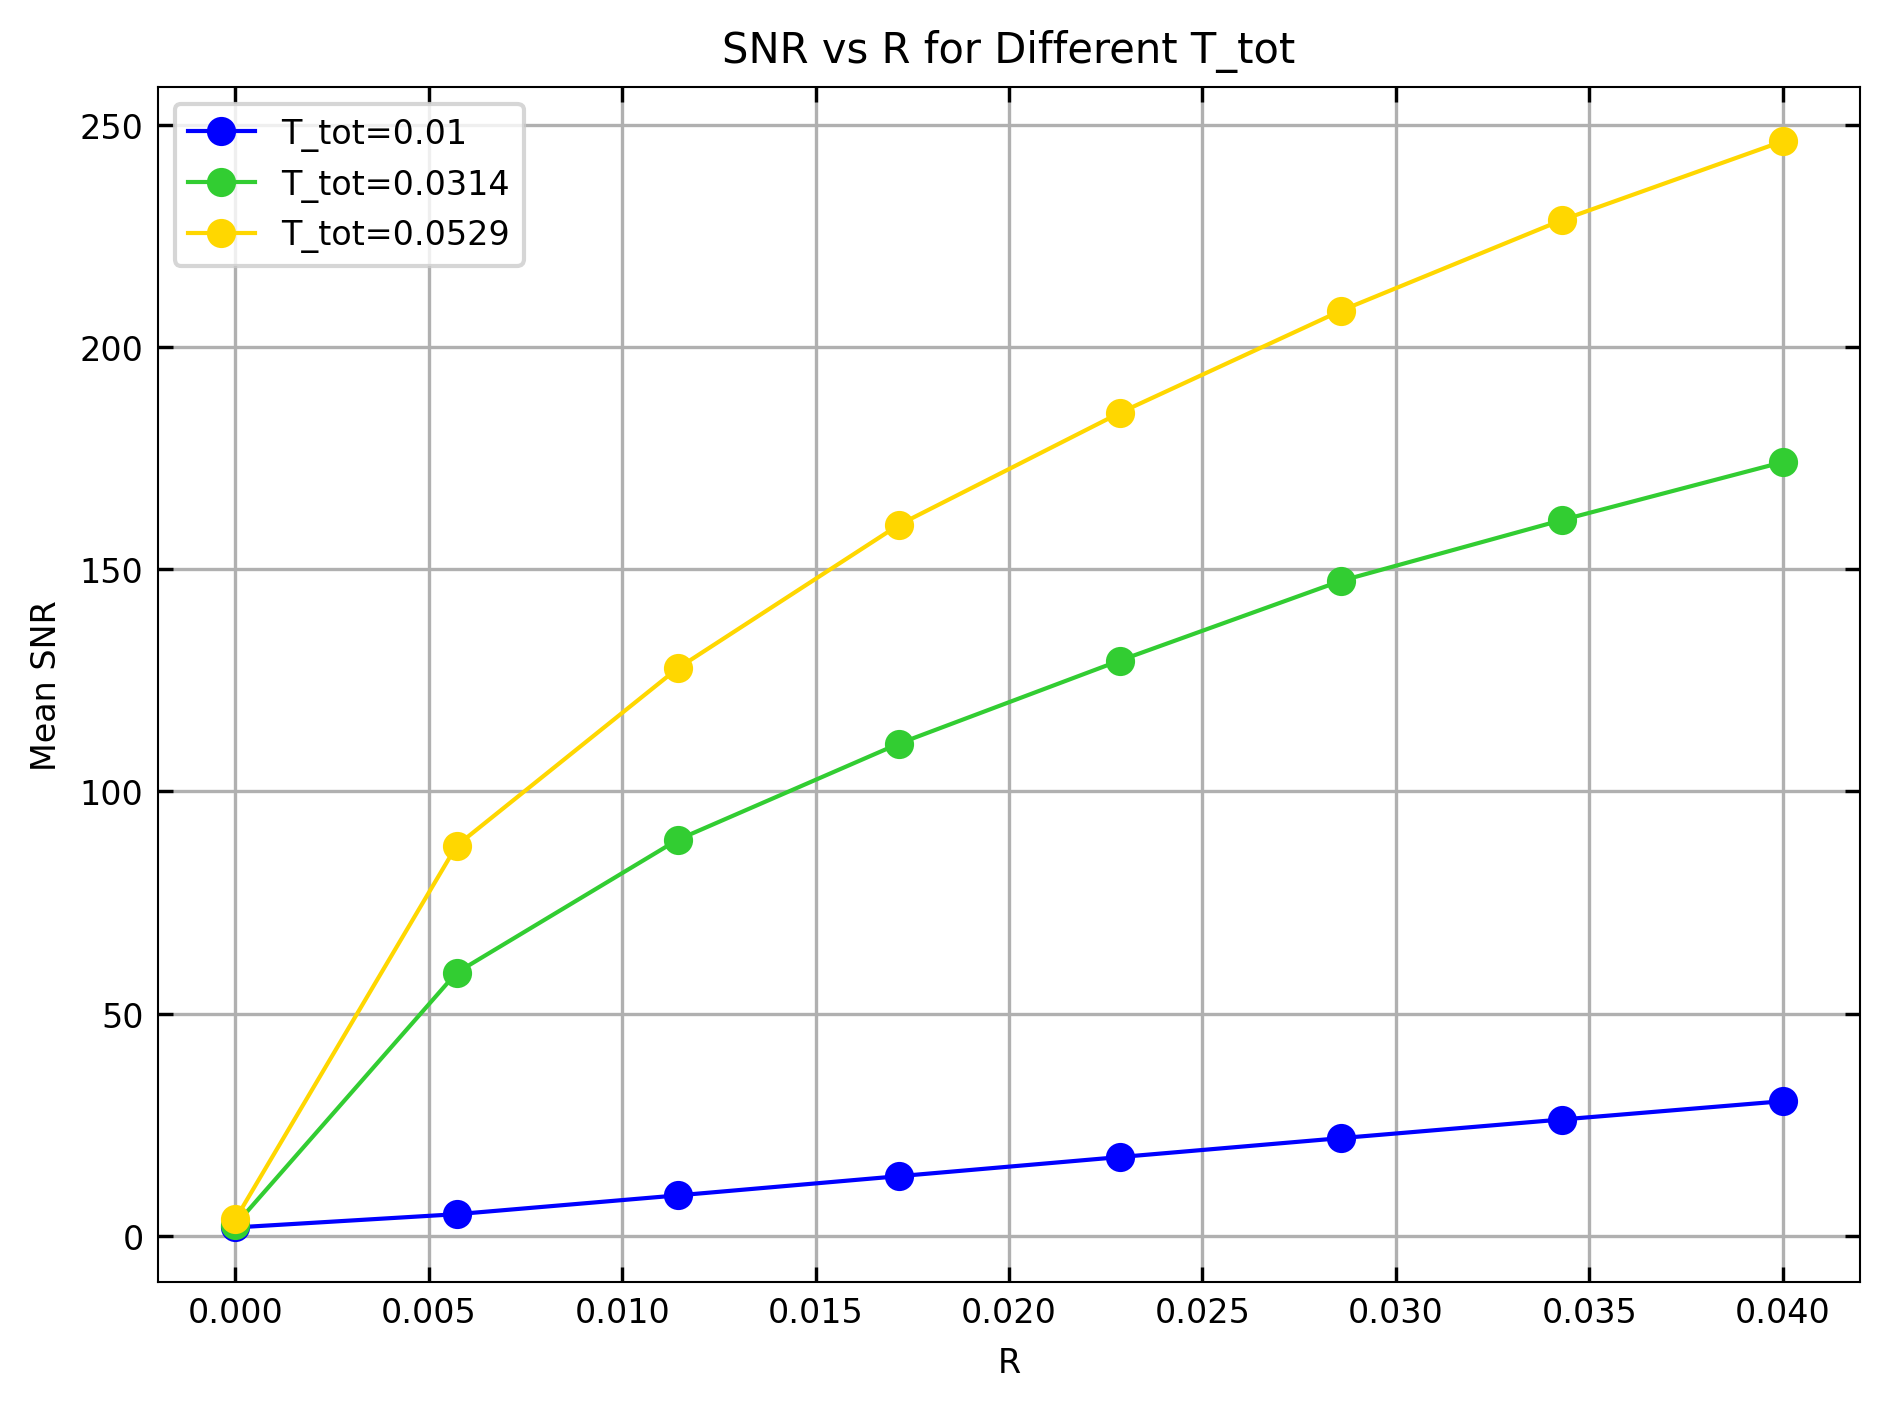

In [19]:
# SNR vs parameter conditioned on T_tot

R_vals = np.unique(param_stack[:, param_names.index('R')])
T_vals = np.unique(param_stack[:, param_names.index('T_tot')])

plt.figure()
for T in T_vals[::3]:
    mask = param_stack[:, param_names.index('T_tot')] == T
    mean_snr = [snr_flat[mask & (param_stack[:, param_names.index('R')] == R)].mean()
                for R in R_vals]
    plt.plot(R_vals, mean_snr, marker='o', label=f'T_tot={T:.3g}')

plt.xlabel('R')
plt.ylabel('Mean SNR')
plt.title('SNR vs R for Different T_tot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


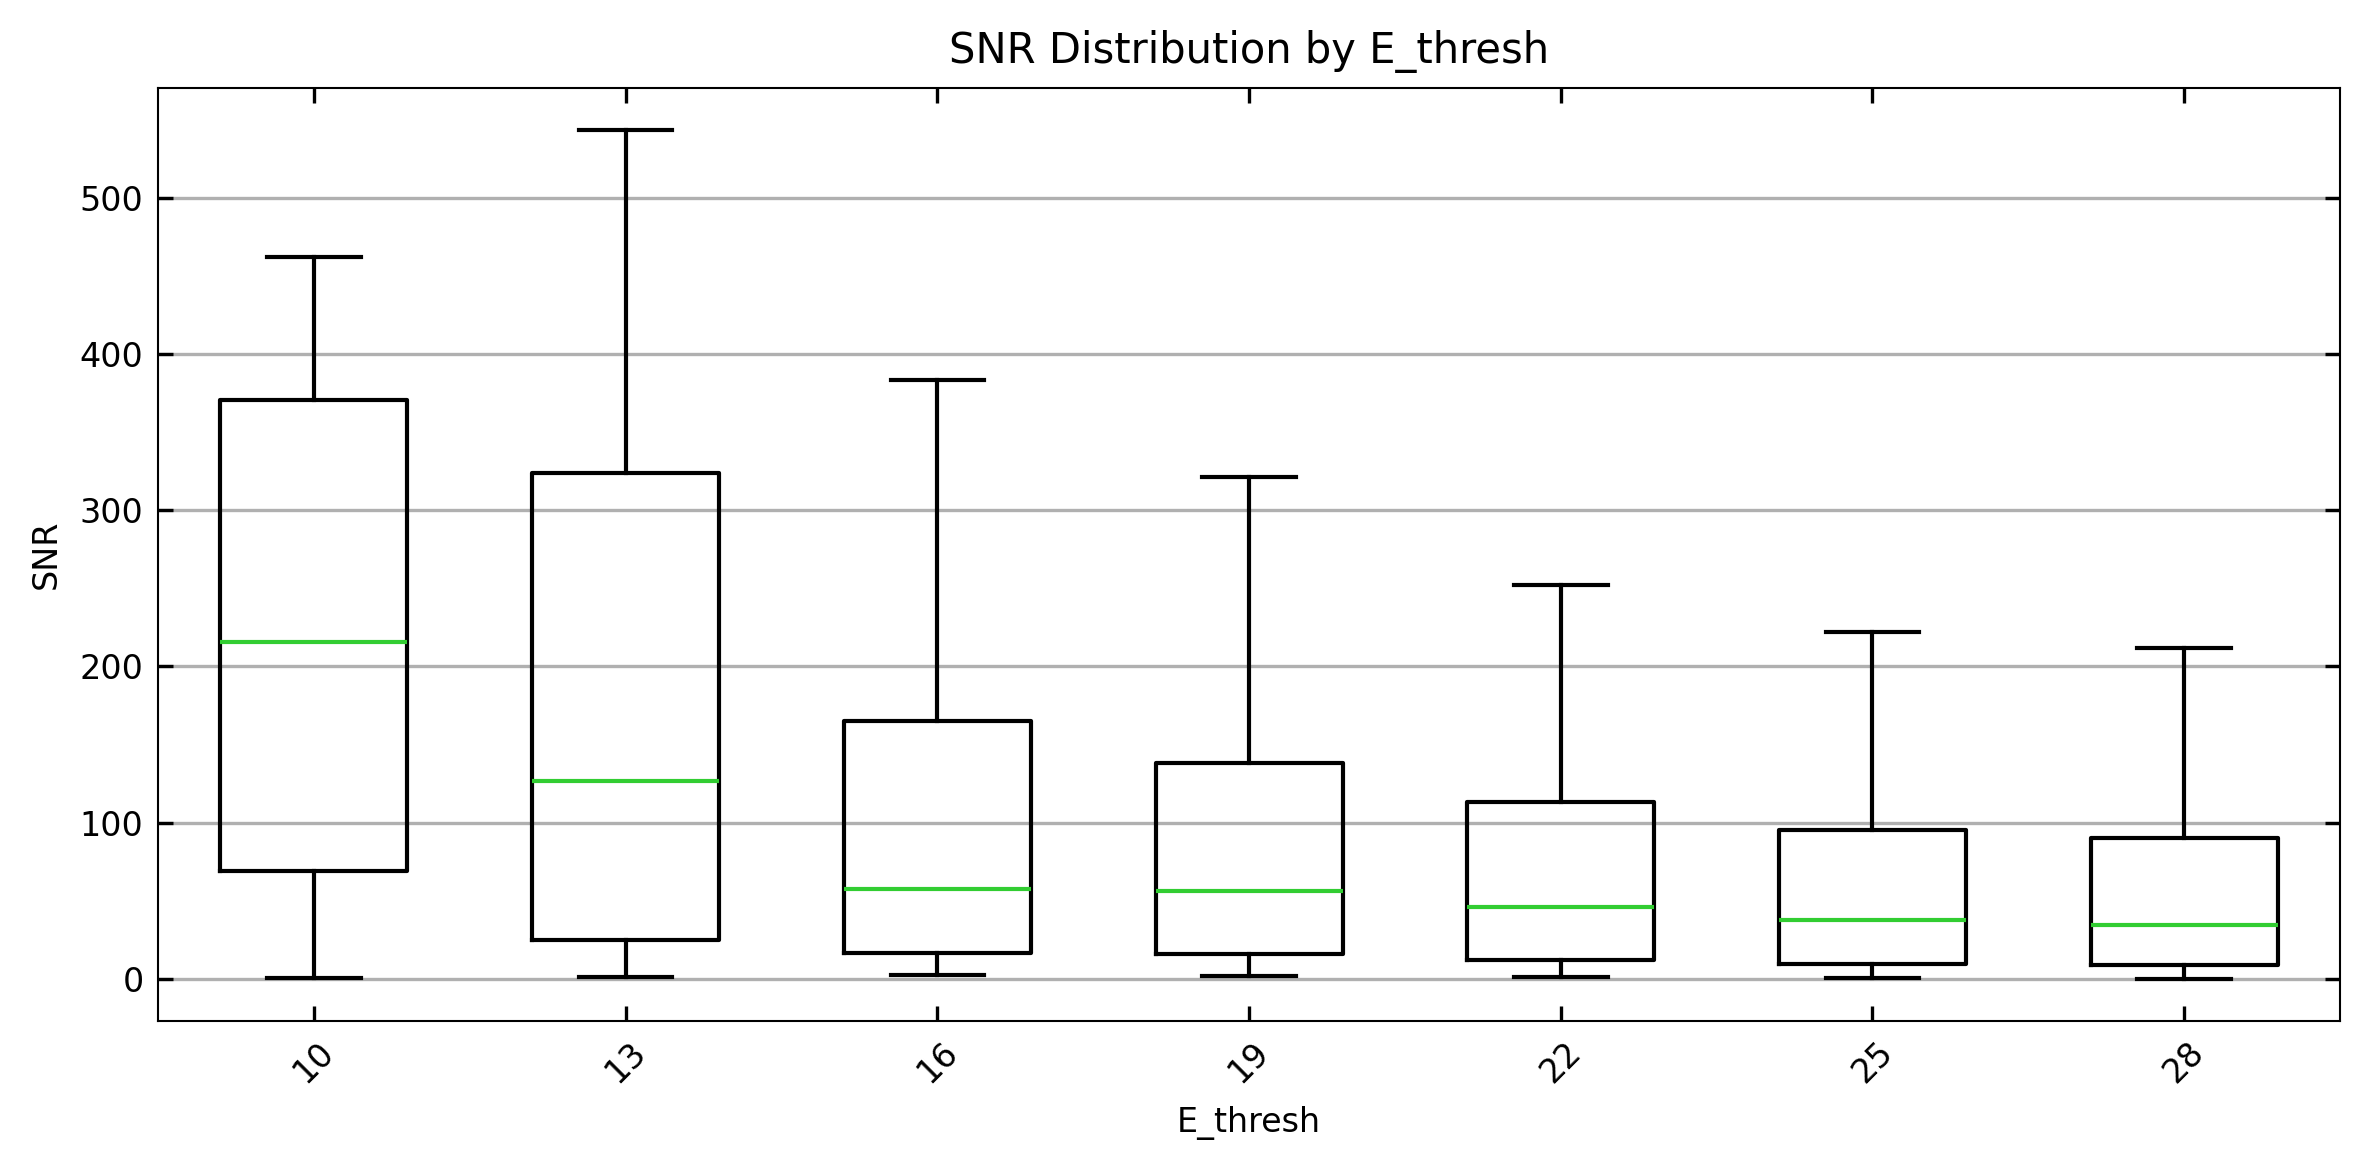

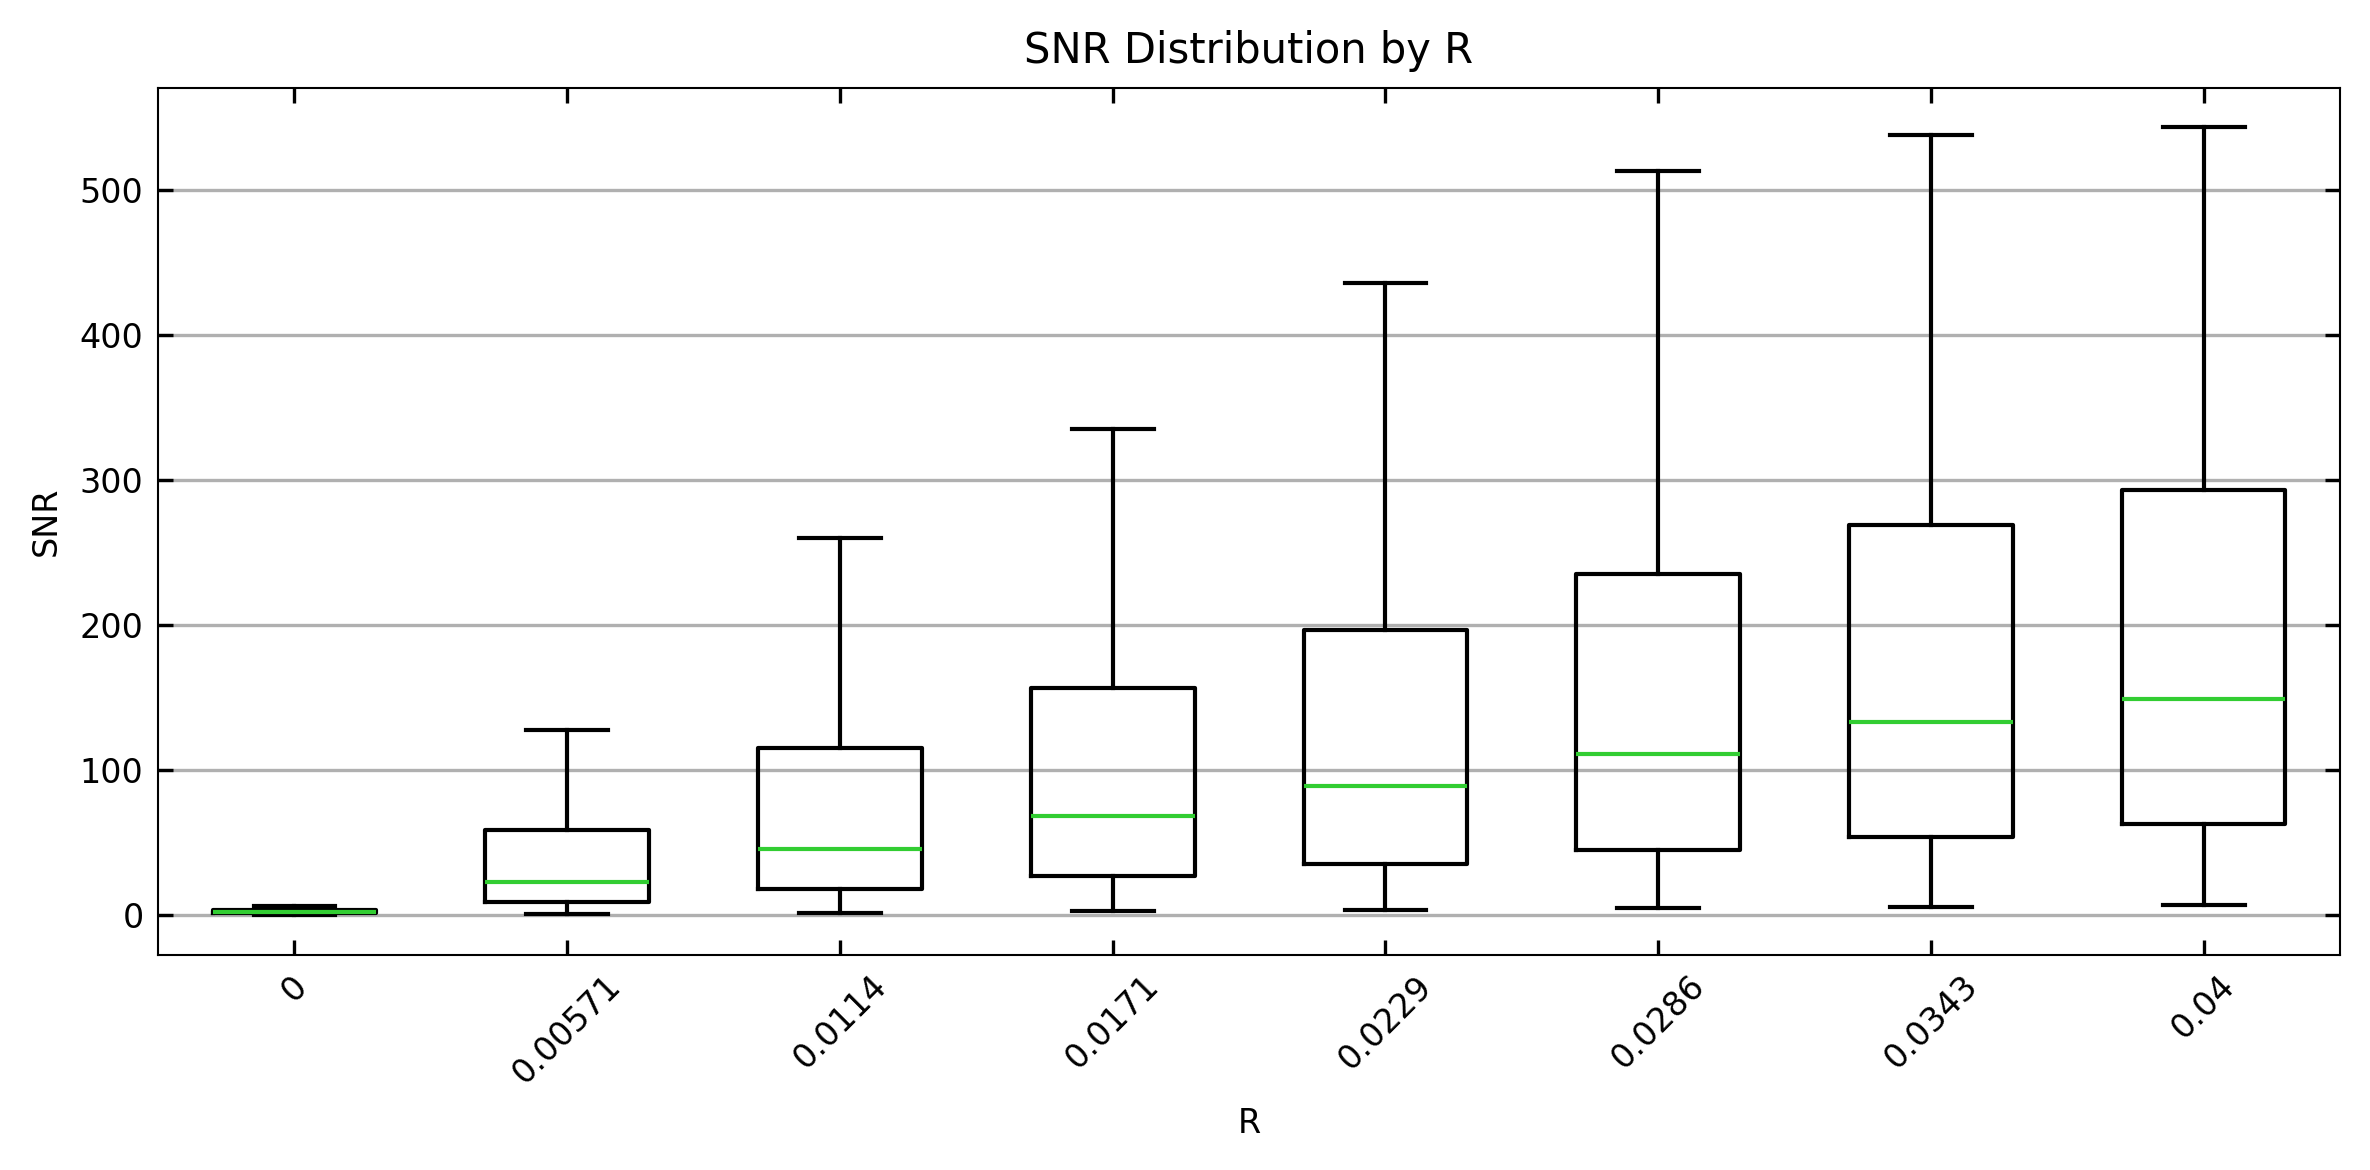

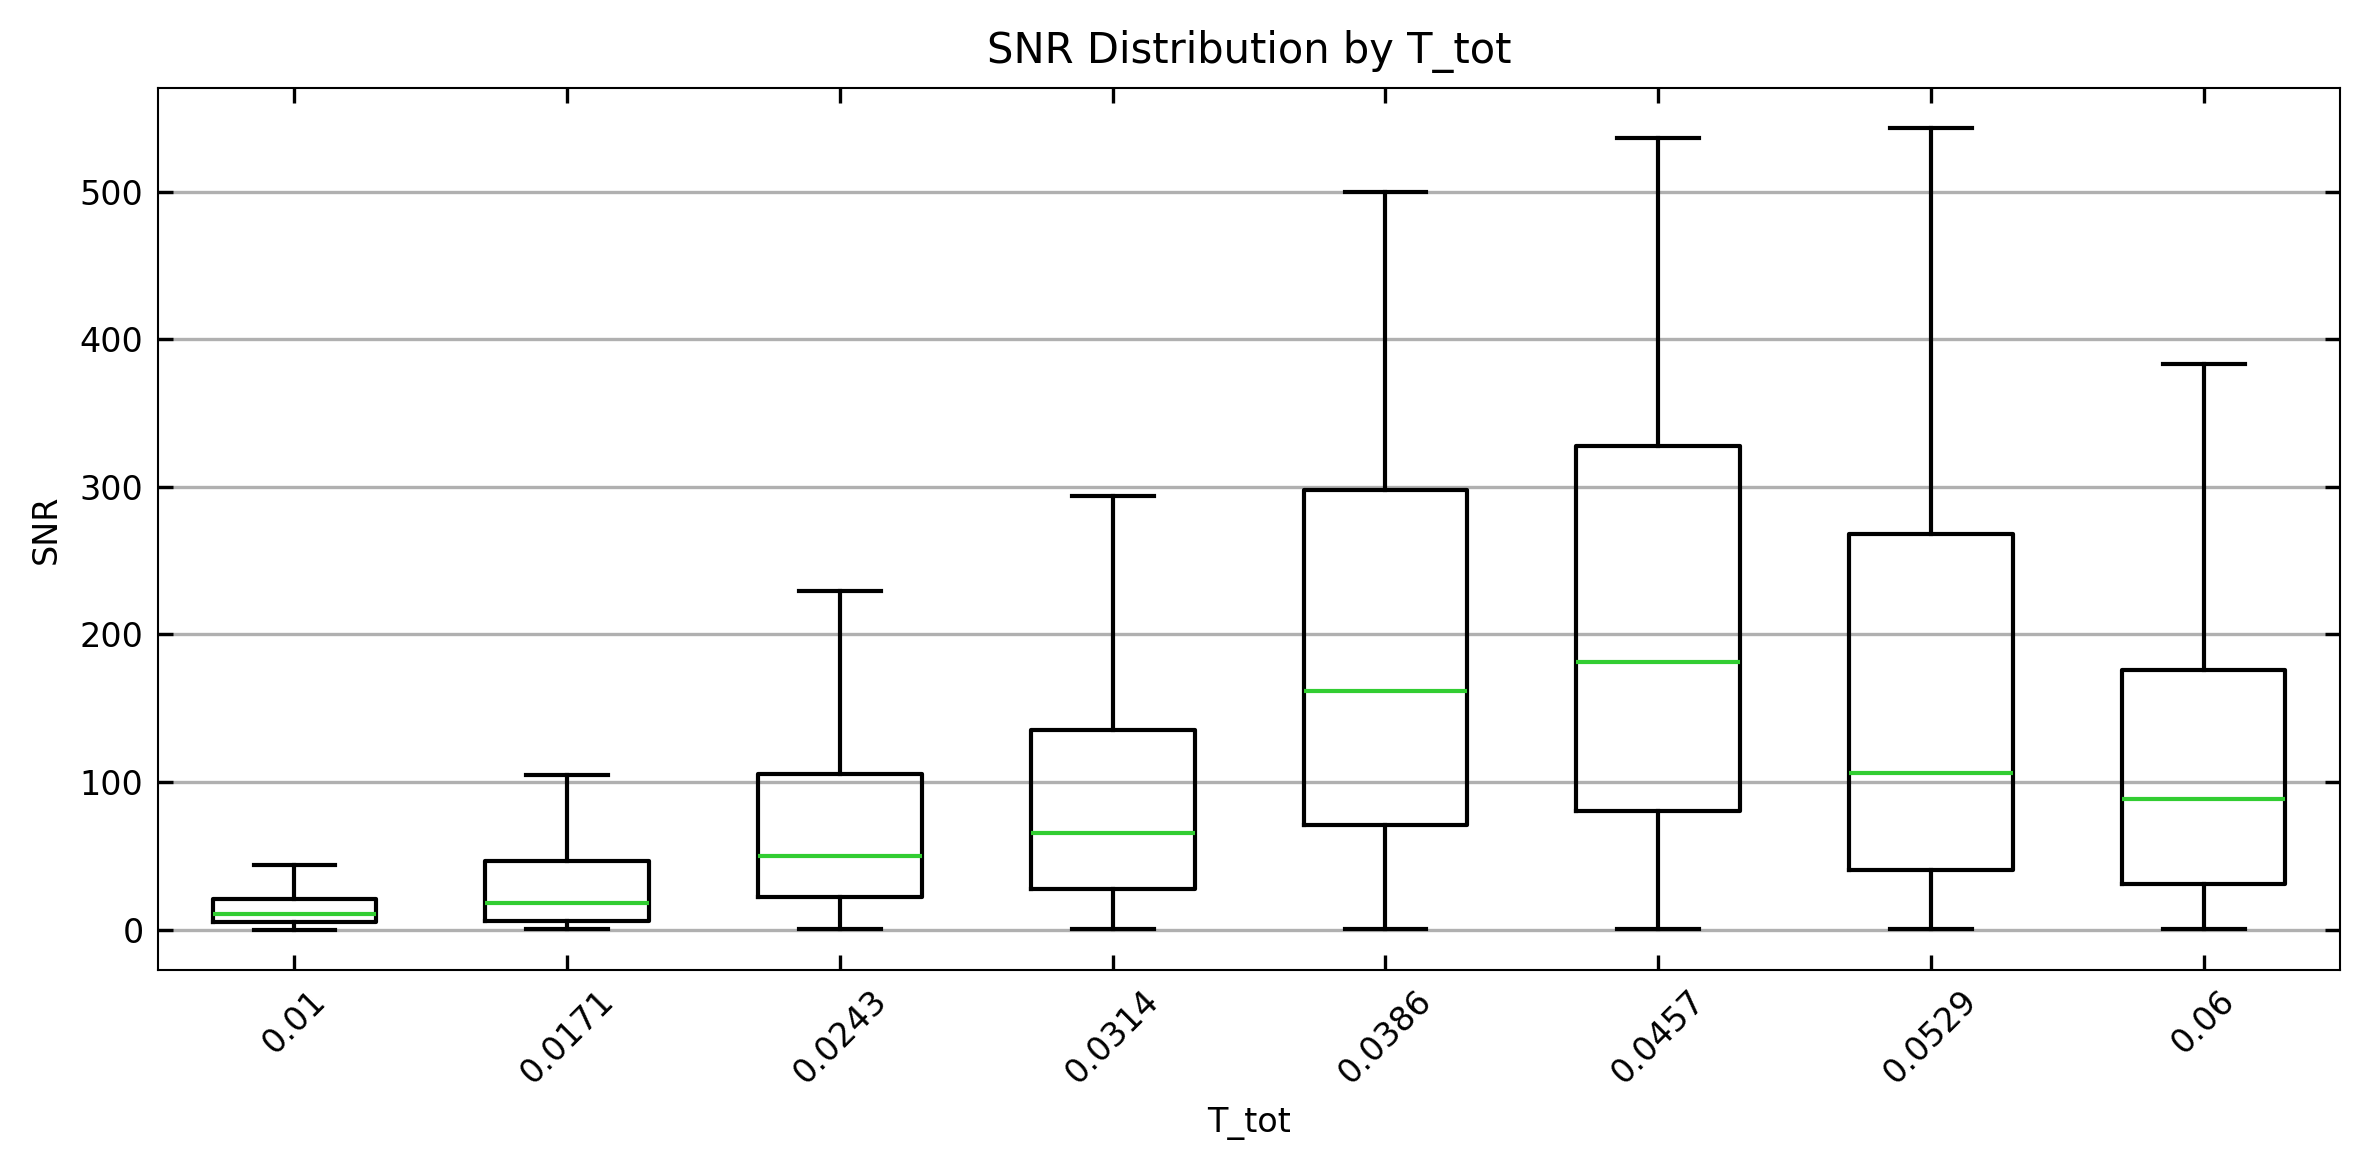

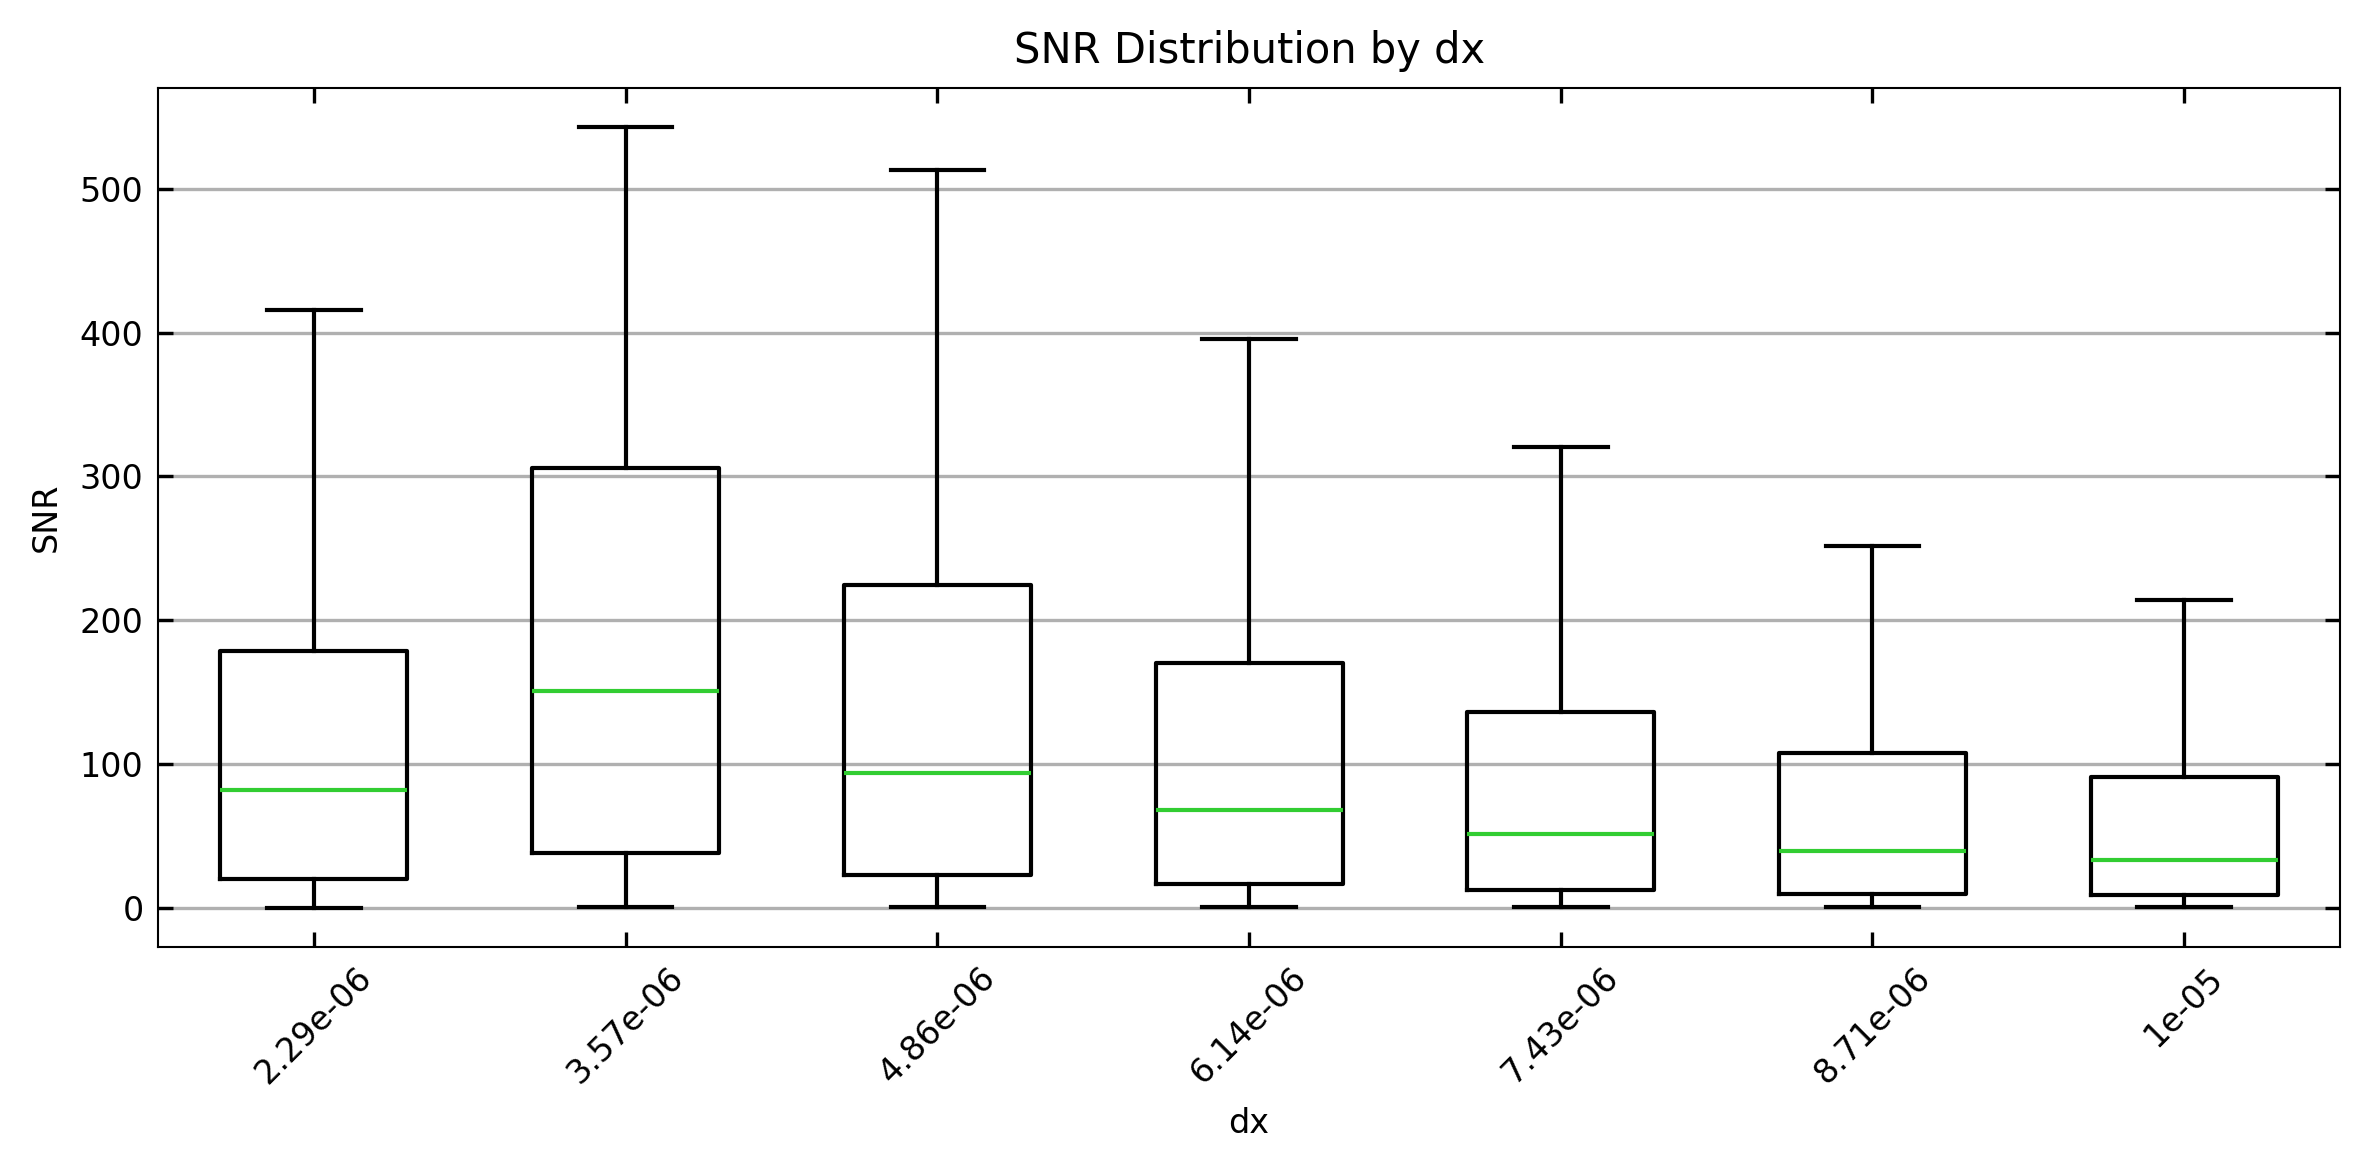

In [22]:
# box plots
for i, name in enumerate(param_names):
    values = param_stack[:, i]
    unique_vals = np.unique(values)
    groups = []

    for val in unique_vals:
        group_snr = snr_flat[values == val]
        if len(group_snr) > 0:
            groups.append(group_snr)

    plt.figure(figsize=(8, 4))
    plt.boxplot(groups, positions=np.arange(len(unique_vals)), widths=0.6, showfliers=False)
    plt.xticks(ticks=np.arange(len(unique_vals)), labels=[f"{v:.3g}" for v in unique_vals], rotation=45)
    plt.xlabel(name)
    plt.ylabel("SNR")
    plt.title(f"SNR Distribution by {name}")
    plt.tight_layout()
    plt.grid(True, axis='y')
    plt.show()

## Test plots

In [23]:
%%time

npts = 8
E_threshs = np.linspace(10, 31, npts)    # polychrom spectral threshold [keV]
Rs = 1e-3 * np.linspace(0, 40, npts)     # propagation distance [m]
T_tots = 1e-2 * np.linspace(1, 6, npts)  # total object thickness [m]
dxs = 1e-6 * np.linspace(1, 10, npts)    # pixel size [m]
Fs = np.linspace(0.2, 0.8, npts)

pars = jnp.array([(E, R, F, T_tot, dx) 
                  for E in E_threshs 
                  for R in Rs
                  for F in Fs
                  for T_tot in T_tots
                  for dx in dxs
                 ])

partial_frac_spectral = partial(crlb.compute_frac_spectral, 
    spectrum = spectrum, 
    eta = np.ones(spectrum.shape[1]),
    Nx = 64, 
    obj_radius = 100e-6,  #32e-6,
    mat1 = gland,
    mat2 = adip
)

@jax.jit
@jax.vmap
def sweep_frac_spectral(pars):
    E, R, F, T_tot, dx = pars
    return partial_frac_spectral(E_thresh=E, R=R, T1=F*T_tot, T_tot=T_tot, dx=dx)

var, snr = sweep_frac_spectral(pars)



CPU times: user 3.09 s, sys: 132 ms, total: 3.22 s
Wall time: 1.91 s


In [ ]:
%%time

## show
snr_matrix = snr.reshape([E_threshs.size, Rs.size, Fs.size, T_tots.size, dxs.size])

param_grids = [E_threshs, Rs, Fs, T_tots, dxs]
param_names = ['E_thresh', 'R', 'F', 'T_tot', 'dx']

plot_parallel_coordinates(snr_matrix, param_grids, param_names, top_n=500)


In [ ]:
%%time

# Define axes
F_vals = param_grids[2]
T_vals = param_grids[3] * 1e3  # mm

best_E = np.full((len(F_vals), len(T_vals)), np.nan)

for iF, F in enumerate(F_vals):
    for iT, T in enumerate(T_vals):
        # Slice SNR matrix at fixed F, T_tot
        snr_slice = snr_matrix[:, :, iF, iT, :]

        # Flatten over remaining acquisition parameters (E, R, dx)
        snr_flat = snr_slice.reshape(-1)

        if np.all(np.isnan(snr_flat)):
            continue

        # Index of max SNR
        max_idx = np.nanargmax(snr_flat)

        # Get corresponding (E, R, dx) indices
        iE, iR, iDx = np.unravel_index(max_idx, snr_slice.shape)

        # Record E_thresh value
        best_E[iF, iT] = E_threshs[iE]

# Plot heatmap: best E_thresh per (F, T_tot)
plt.figure(figsize=(10, 6))
im = plt.imshow(best_E, aspect='auto', cmap='viridis',
                extent=[T_vals[0], T_vals[-1], F_vals[0], F_vals[-1]],
                origin='lower')  # lower-left corner is (min F, min T)

plt.colorbar(im, label='Optimal E_thresh (keV)')
plt.xlabel('T_tot (mm)')
plt.ylabel('F (Material Fraction)')
plt.title('E_thresh Value that Maximized SNR')
plt.tight_layout()
plt.show()